In [8]:
pip install pandas matplotlib

In [9]:
pip install pandas matplotlib openpyxl

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/CSV DS/hotel_bookings.csv')

In [ ]:
#Jika mmenjalankan dengan upload dataset
data = pd.read_csv ('/content/hotel_bookings.csv')

In [ ]:
# Berbeda Laptop
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'path/to/your/hotel_bookings.csv'

# Read the Excel file
data = pd.read_excel(file_path)


**<H2>Data Pre-processing & Transformation<H2>**

Data Cleaning

In [3]:
import pandas as pd

# Menangani nilai yang hilang
# Menghapus kolom dengan terlalu banyak nilai hilang (lebih dari 50% hilang)
threshold = len(data) * 0.5
data_cleaned = data.dropna(thresh=threshold, axis=1)

# Mengisi nilai yang hilang untuk kolom numerik dengan rata-rata
numerical_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)

# Mengisi nilai yang hilang untuk kolom kategorikal dengan modus
categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)

# Menghapus baris duplikat
data_cleaned = data_cleaned.drop_duplicates()

# Menampilkan beberapa baris dari dataset yang telah dibersihkan
data_cleaned.head()


<ipython-input-3-aad736843fa0>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
<ipython-input-3-aad736843fa0>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,86.693382,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,86.693382,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,86.693382,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.000000,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.000000,0,Transient,98.0,0,1,Check-Out,2015-07-03


Data Transformation

In [4]:
# Mengonversi variabel kategorikal menjadi numerik menggunakan one-hot encoding
categorical_columns = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'country']
data_transformed = pd.get_dummies(data_cleaned, columns=categorical_columns)

# Menampilkan beberapa baris dari dataset yang telah ditransformasikan
data_transformed.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_UMI,country_URY,country_USA,country_UZB,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE
0,0,342,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,False,False
2,0,7,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,False,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,False,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,False,False,False,False,False,False,False,False,False,False


Data Discrezation

In [5]:
# Mendiskretisasi kolom 'lead_time' menjadi beberapa kategori
data_discretized = data_transformed.copy()
data_discretized['lead_time_bins'] = pd.cut(data_discretized['lead_time'], bins=5, labels=['sangat pendek', 'pendek', 'sedang', 'panjang', 'sangat panjang'])
data_discretized.drop(columns=['lead_time'], inplace=True)

# Menampilkan beberapa baris dari dataset yang telah didiskretisasi
data_discretized.head()

,is_canceled,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,country_URY,country_USA,country_UZB,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,lead_time_bins
0,0,2015,27,1,0,0,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,sedang
1,0,2015,27,1,0,0,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,sangat panjang
2,0,2015,27,1,0,1,1,0.0,0,0,...,False,False,False,False,False,False,False,False,False,sangat pendek
3,0,2015,27,1,0,1,1,0.0,0,0,...,False,False,False,False,False,False,False,False,False,sangat pendek
4,0,2015,27,1,0,2,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,sangat pendek


Data Normalization

In [6]:
from sklearn.preprocessing import MinMaxScaler

# Menormalisasi fitur numerik
scaler = MinMaxScaler()
numerical_features = ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

data_normalized = data_discretized.copy()
data_normalized[numerical_features] = scaler.fit_transform(data_normalized[numerical_features])

# Menampilkan beberapa baris dari dataset yang telah dinormalisasi
data_normalized.head()

,is_canceled,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,country_URY,country_USA,country_UZB,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,lead_time_bins
0,0,2015,27,1,0.0,0.00,0.036364,0.0,0.0,0,...,False,False,False,False,False,False,False,False,False,sedang
1,0,2015,27,1,0.0,0.00,0.036364,0.0,0.0,0,...,False,False,False,False,False,False,False,False,False,sangat panjang
2,0,2015,27,1,0.0,0.02,0.018182,0.0,0.0,0,...,False,False,False,False,False,False,False,False,False,sangat pendek
3,0,2015,27,1,0.0,0.02,0.018182,0.0,0.0,0,...,False,False,False,False,False,False,False,False,False,sangat pendek
4,0,2015,27,1,0.0,0.04,0.036364,0.0,0.0,0,...,False,False,False,False,False,False,False,False,False,sangat pendek


Future Selection

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

# Menentukan fitur dan target
X = data_normalized.drop(columns=['is_canceled', 'reservation_status_date', 'lead_time_bins'])
y = data_normalized['is_canceled']

# Memilih 10 fitur terbaik
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support(indices=True)]
print("Fitur yang dipilih:", selected_features)

# Menampilkan beberapa baris dari dataset dengan 10 fitur terbaik yang dipilih
X_selected = data_normalized[selected_features]
X_selected.head()


Fitur yang dipilih: Index(['adr', 'required_car_parking_spaces', 'market_segment_Online TA',
       'distribution_channel_TA/TO', 'deposit_type_No Deposit',
       'deposit_type_Non Refund', 'customer_type_Transient',
       'reservation_status_Canceled', 'reservation_status_Check-Out',
       'reservation_status_No-Show'],
      dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


,adr,required_car_parking_spaces,market_segment_Online TA,distribution_channel_TA/TO,deposit_type_No Deposit,deposit_type_Non Refund,customer_type_Transient,reservation_status_Canceled,reservation_status_Check-Out,reservation_status_No-Show
0,0.001180,0.0,False,False,True,False,True,False,True,False
1,0.001180,0.0,False,False,True,False,True,False,True,False
2,0.015053,0.0,False,False,True,False,True,False,True,False
3,0.015053,0.0,False,False,True,False,True,False,True,False
4,0.019307,0.0,True,True,True,False,True,False,True,False


**<H2>Distribusi Data dari target kelas is_canceled dan reservation_status<H2>**

is_canceled

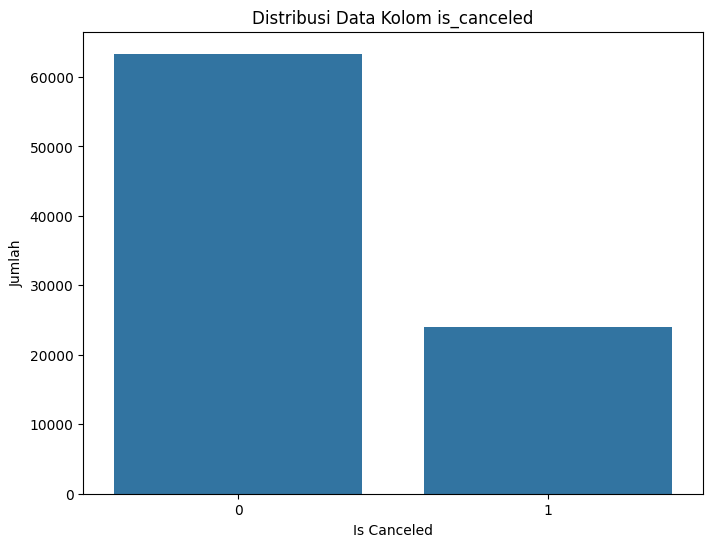

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi data kolom is_canceled
plt.figure(figsize=(8, 6))
sns.countplot(x='is_canceled', data=data_cleaned)
plt.title('Distribusi Data Kolom is_canceled')
plt.xlabel('Is Canceled')
plt.ylabel('Jumlah')
plt.show()


reservation_status

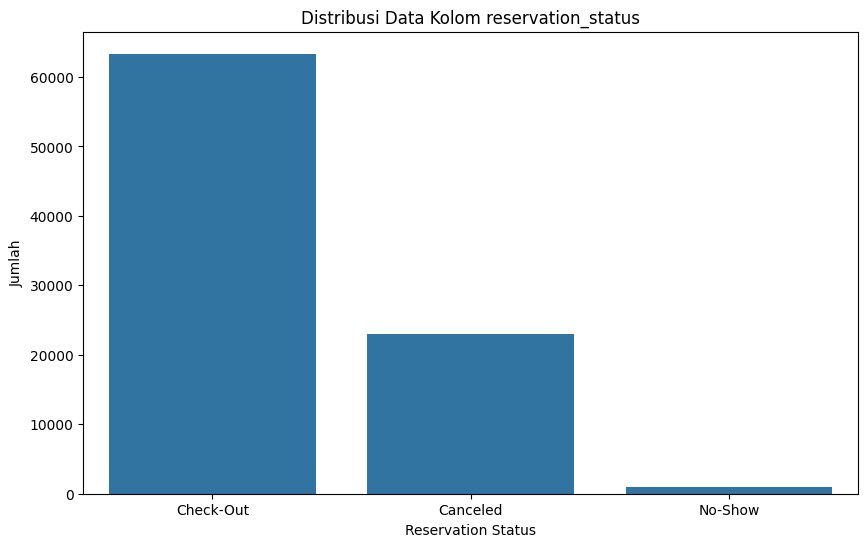

In [ ]:
# Distribusi data kolom reservation_status
plt.figure(figsize=(10, 6))
sns.countplot(x='reservation_status', data=data_cleaned, order=data_cleaned['reservation_status'].value_counts().index)
plt.title('Distribusi Data Kolom reservation_status')
plt.xlabel('Reservation Status')
plt.ylabel('Jumlah')
plt.show()


**<h2>Algoritma Yang Digunakan pada kolom is_canceled & reservation_status (Sebelum di Resampeld)**<h2>

is_canceeled

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import matplotlib.pyplot as plt


# Menangani nilai yang hilang
threshold = len(data) * 0.5
data_cleaned = data.dropna(thresh=threshold, axis=1)
numerical_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)
data_cleaned = data_cleaned.drop_duplicates()

# Mengonversi variabel kategorikal menjadi numerik menggunakan one-hot encoding
categorical_columns = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'country']
data_transformed = pd.get_dummies(data_cleaned, columns=categorical_columns)

# Mendiskretisasi kolom 'lead_time' menjadi beberapa kategori
data_discretized = data_transformed.copy()
data_discretized['lead_time_bins'] = pd.cut(data_discretized['lead_time'], bins=5, labels=['sangat pendek', 'pendek', 'sedang', 'panjang', 'sangat panjang'])
data_discretized.drop(columns=['lead_time'], inplace=True)

# Menormalisasi fitur numerik
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numerical_features = ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
data_normalized = data_discretized.copy()
data_normalized[numerical_features] = scaler.fit_transform(data_normalized[numerical_features])

# Menghapus kolom yang tidak relevan
X = data_normalized.drop(columns=['is_canceled', 'reservation_status_date', 'lead_time_bins'])
y = data_normalized['is_canceled']

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<ipython-input-12-c8ff701a3086>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
<ipython-input-12-c8ff701a3086>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


Naive Baiyes

Naive Bayes Accuracy: 1.0
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12732
           1       1.00      1.00      1.00      4742

    accuracy                           1.00     17474
   macro avg       1.00      1.00      1.00     17474
weighted avg       1.00      1.00      1.00     17474



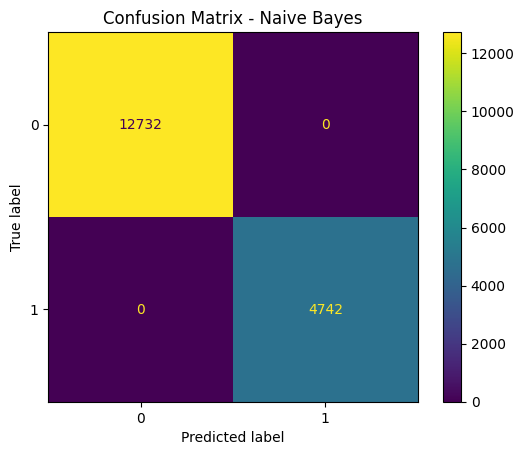

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Melatih model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Memprediksi
y_pred_nb = nb_model.predict(X_test)

# Accuracy dan Classification Report
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()


Decision Tree

Decision Tree Accuracy: 1.0
Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12732
           1       1.00      1.00      1.00      4742

    accuracy                           1.00     17474
   macro avg       1.00      1.00      1.00     17474
weighted avg       1.00      1.00      1.00     17474



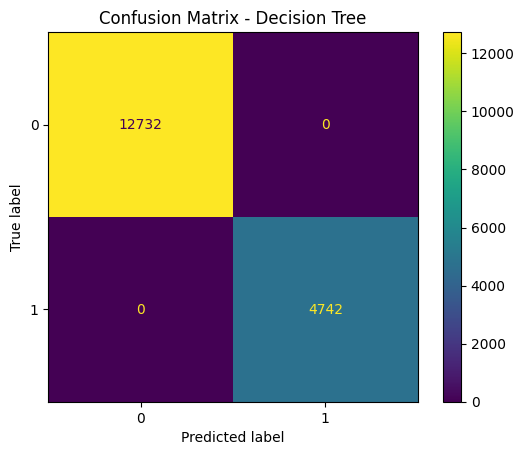

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Melatih model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Memprediksi
y_pred_dt = dt_model.predict(X_test)

# Accuracy dan Classification Report
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_model.classes_)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()


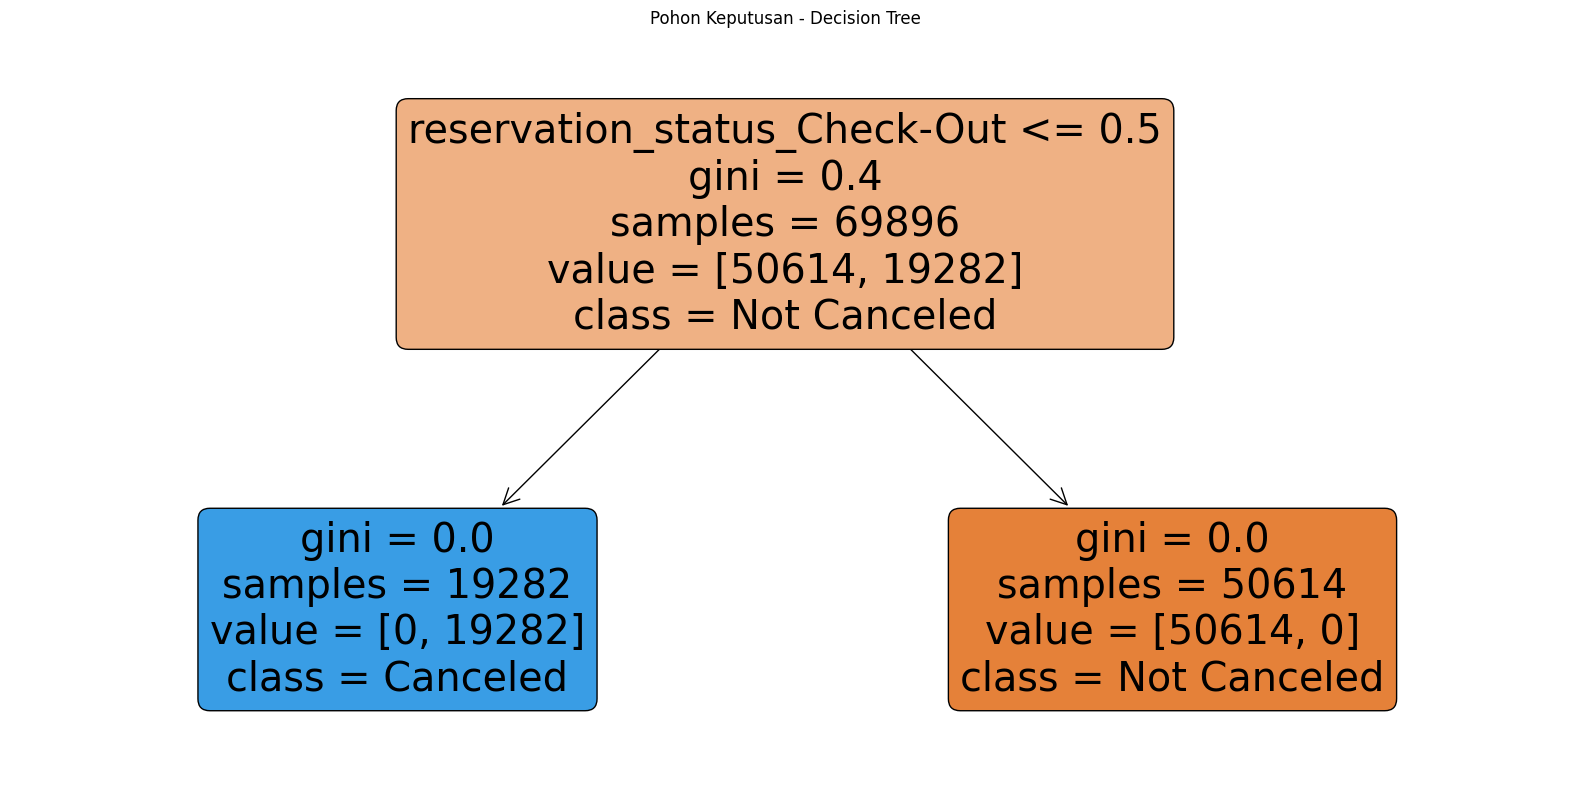

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Melatih model
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)  # Menggunakan max_depth=3 untuk kesederhanaan
dt_model.fit(X_train, y_train)

# Visualisasi pohon keputusan
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Not Canceled', 'Canceled'], filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()


Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 1.0
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12732
           1       1.00      1.00      1.00      4742

    accuracy                           1.00     17474
   macro avg       1.00      1.00      1.00     17474
weighted avg       1.00      1.00      1.00     17474



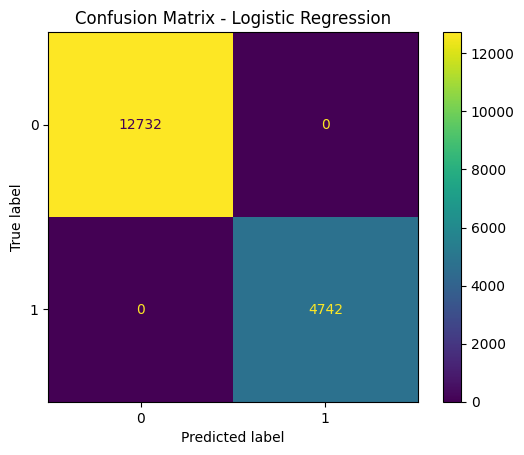

In [ ]:
from sklearn.linear_model import LogisticRegression

# Melatih model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Memprediksi
y_pred_lr = lr_model.predict(X_test)

# Accuracy dan Classification Report
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Random Forest

Random Forest Accuracy: 1.0
Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12732
           1       1.00      1.00      1.00      4742

    accuracy                           1.00     17474
   macro avg       1.00      1.00      1.00     17474
weighted avg       1.00      1.00      1.00     17474



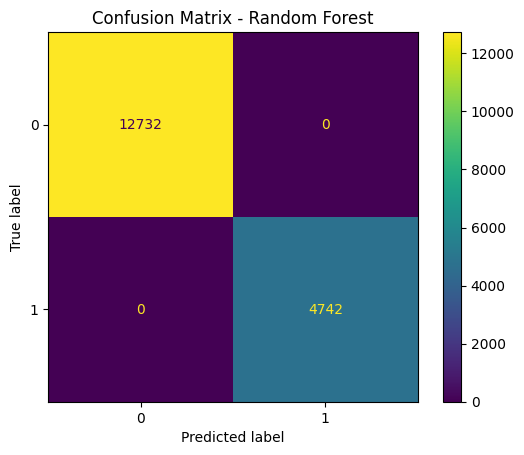

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Melatih model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Memprediksi
y_pred_rf = rf_model.predict(X_test)

# Accuracy dan Classification Report
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()

XGBoost

XGBoost Accuracy: 1.0
Classification Report - XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12732
           1       1.00      1.00      1.00      4742

    accuracy                           1.00     17474
   macro avg       1.00      1.00      1.00     17474
weighted avg       1.00      1.00      1.00     17474



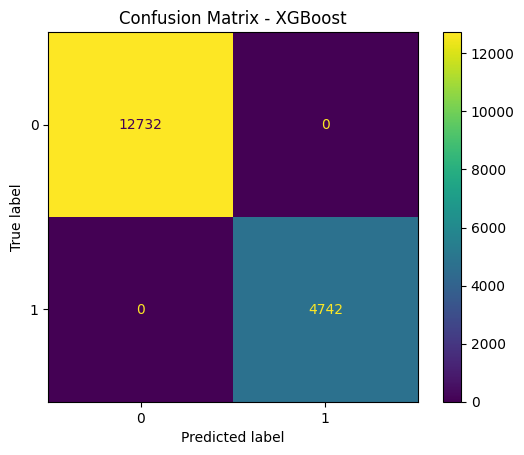

In [ ]:
import xgboost as xgb

# Melatih model
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Memprediksi
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy dan Classification Report
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_model.classes_)
disp_xgb.plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()


reservation_status

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Menangani nilai yang hilang
threshold = len(data) * 0.5
data_cleaned = data.dropna(thresh=threshold, axis=1)
numerical_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)
data_cleaned = data_cleaned.drop_duplicates()

# Mengonversi variabel kategorikal menjadi numerik menggunakan one-hot encoding
categorical_columns = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'country']
data_transformed = pd.get_dummies(data_cleaned, columns=categorical_columns)

# Mendiskretisasi kolom 'lead_time' menjadi beberapa kategori
data_discretized = data_transformed.copy()
data_discretized['lead_time_bins'] = pd.cut(data_discretized['lead_time'], bins=5, labels=['sangat pendek', 'pendek', 'sedang', 'panjang', 'sangat panjang'])
data_discretized.drop(columns=['lead_time'], inplace=True)

# Menormalisasi fitur numerik
scaler = MinMaxScaler()
numerical_features = ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
data_normalized = data_discretized.copy()
data_normalized[numerical_features] = scaler.fit_transform(data_normalized[numerical_features])

# Mengonversi target menjadi numerik
label_encoder = LabelEncoder()
data_normalized['reservation_status'] = label_encoder.fit_transform(data_normalized['reservation_status'])

# Menghapus kolom yang tidak relevan
X = data_normalized.drop(columns=['reservation_status', 'reservation_status_date', 'lead_time_bins'])
y = data_normalized['reservation_status']

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<ipython-input-19-df397b7c4740>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
<ipython-input-19-df397b7c4740>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


Naive Baiyes

Naive Bayes Accuracy: 0.771489069474648
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

           0       0.99      0.12      0.21      4526
           1       1.00      1.00      1.00     12732
           2       0.05      0.96      0.09       216

    accuracy                           0.77     17474
   macro avg       0.68      0.69      0.44     17474
weighted avg       0.98      0.77      0.79     17474



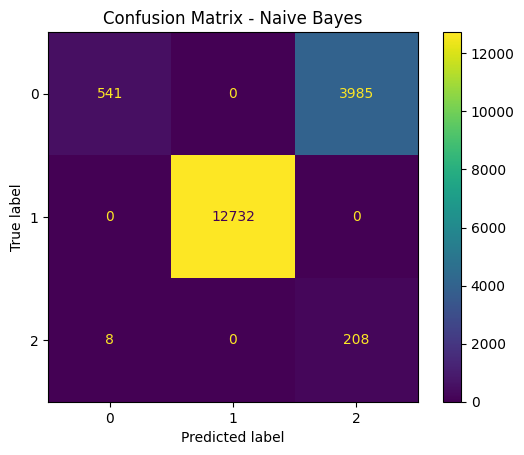

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# Melatih model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Memprediksi
y_pred_nb = nb_model.predict(X_test)


# Accuracy dan Classification Report
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()


Decision Tree

Decision Tree Accuracy: 0.9876387776124528
Classification Report - Decision Tree:
              precision    recall  f1-score   support

    Canceled       0.95      1.00      0.98      4526
   Check-Out       1.00      1.00      1.00     12732
     No-Show       0.00      0.00      0.00       216

    accuracy                           0.99     17474
   macro avg       0.65      0.67      0.66     17474
weighted avg       0.98      0.99      0.98     17474



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


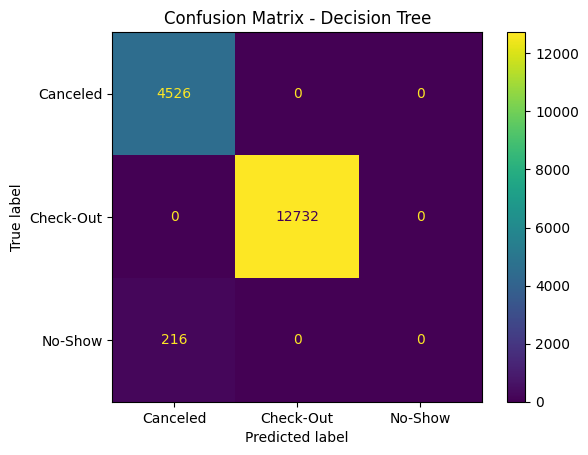

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Memprediksi
y_pred_dt = dt_model.predict(X_test)

# Accuracy dan Classification Report
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=label_encoder.classes_)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()


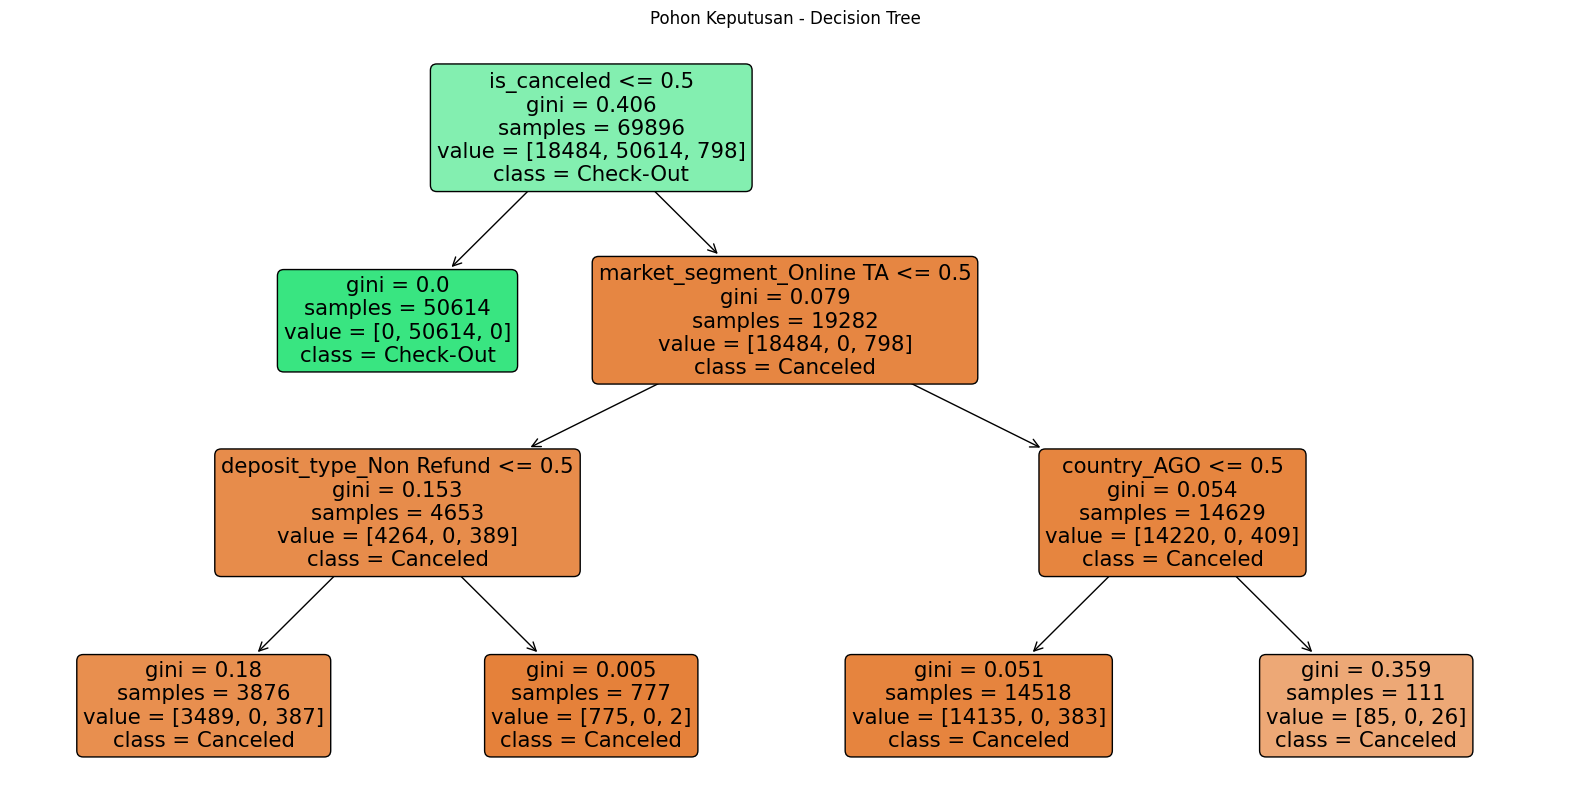

In [ ]:
# Melatih model
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)  # Menggunakan max_depth=3 untuk kesederhanaan
dt_model.fit(X_train, y_train)

# Visualisasi pohon keputusan
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=label_encoder.classes_, filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()

Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.987581549731029
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      4526
           1       1.00      1.00      1.00     12732
           2       0.50      0.00      0.01       216

    accuracy                           0.99     17474
   macro avg       0.82      0.67      0.66     17474
weighted avg       0.98      0.99      0.98     17474



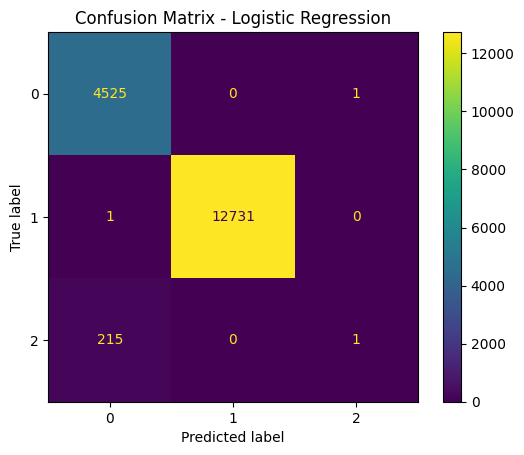

In [ ]:
from sklearn.linear_model import LogisticRegression

# Melatih model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Memprediksi
y_pred_lr = lr_model.predict(X_test)


# Accuracy dan Classification Report
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


Random Forest

Random Forest Accuracy: 0.987924917019572
Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4526
           1       1.00      1.00      1.00     12732
           2       0.65      0.05      0.09       216

    accuracy                           0.99     17474
   macro avg       0.87      0.68      0.69     17474
weighted avg       0.98      0.99      0.98     17474



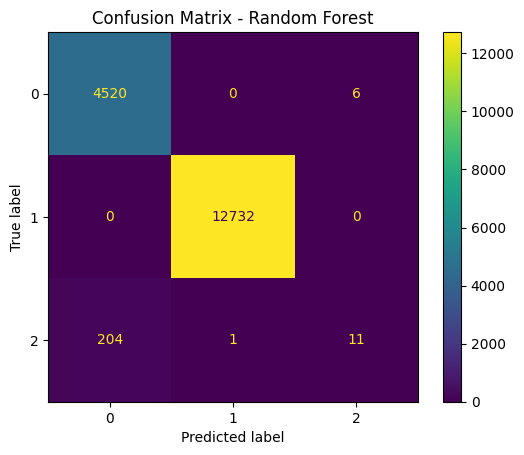

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Melatih model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Memprediksi
y_pred_rf = rf_model.predict(X_test)

# Accuracy dan Classification Report
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()



XGBoost

XGBoost Accuracy: 0.988554423715234
Classification Report - XGBoost:
              precision    recall  f1-score   support

    Canceled       0.96      1.00      0.98      4526
   Check-Out       1.00      1.00      1.00     12732
     No-Show       0.65      0.16      0.26       216

    accuracy                           0.99     17474
   macro avg       0.87      0.72      0.75     17474
weighted avg       0.99      0.99      0.99     17474



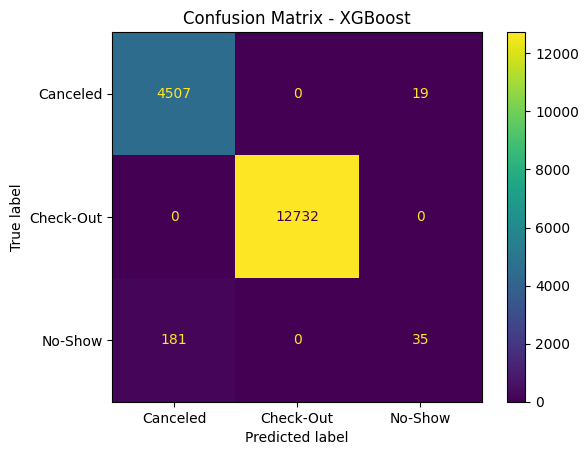

In [ ]:
import xgboost as xgb

# Melatih model
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Memprediksi
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy dan Classification Report
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=label_encoder.classes_)
disp_xgb.plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()


**<h2>Distribusi Data Yang Seimbang dari target kelas is_canceled & reservation_status<h2>**

is_canceled

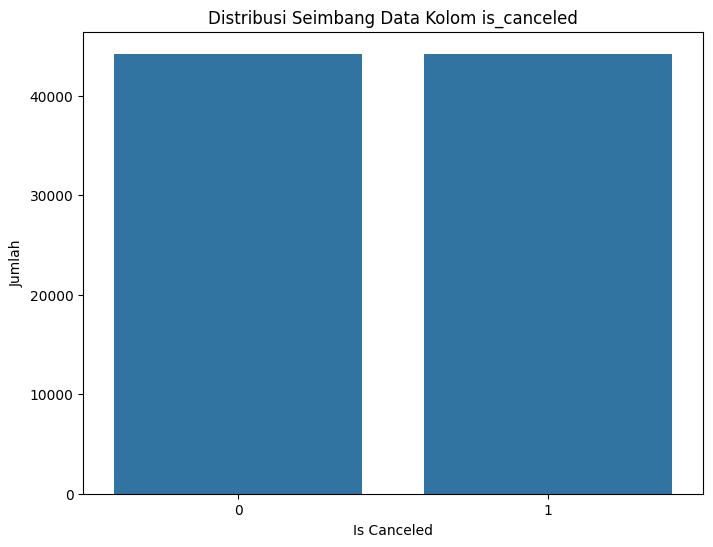

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Menyeimbangkan data dengan undersampling
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(data.drop(columns=['is_canceled']), data['is_canceled'])

# Menggabungkan kembali data yang diseimbangkan
data_balanced_is_canceled = X_resampled.copy()
data_balanced_is_canceled['is_canceled'] = y_resampled

# Distribusi data yang seimbang kolom is_canceled
plt.figure(figsize=(8, 6))
sns.countplot(x='is_canceled', data=data_balanced_is_canceled)
plt.title('Distribusi Seimbang Data Kolom is_canceled')
plt.xlabel('Is Canceled')
plt.ylabel('Jumlah')
plt.show()


reservation_status

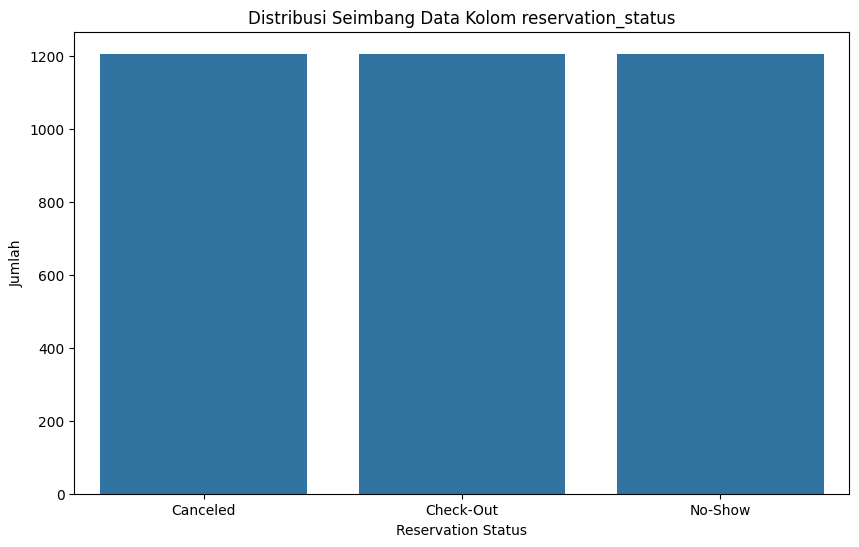

In [ ]:
# Menyeimbangkan data dengan undersampling
X_resampled, y_resampled = rus.fit_resample(data.drop(columns=['reservation_status']), data['reservation_status'])

# Menggabungkan kembali data yang diseimbangkan
data_balanced_reservation_status = X_resampled.copy()
data_balanced_reservation_status['reservation_status'] = y_resampled

# Distribusi data yang seimbang kolom reservation_status
plt.figure(figsize=(10, 6))
sns.countplot(x='reservation_status', data=data_balanced_reservation_status, order=data_balanced_reservation_status['reservation_status'].value_counts().index)
plt.title('Distribusi Seimbang Data Kolom reservation_status')
plt.xlabel('Reservation Status')
plt.ylabel('Jumlah')
plt.show()


**<h2>Distribusi Data Yang Seimbang dari target kelas is_canceled & reservation_status Dengan SMOTE<h2>**

In [ ]:
pip install imbalanced-learn

<ipython-input-31-133a6dc755a2>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
<ipython-input-31-133a6dc755a2>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


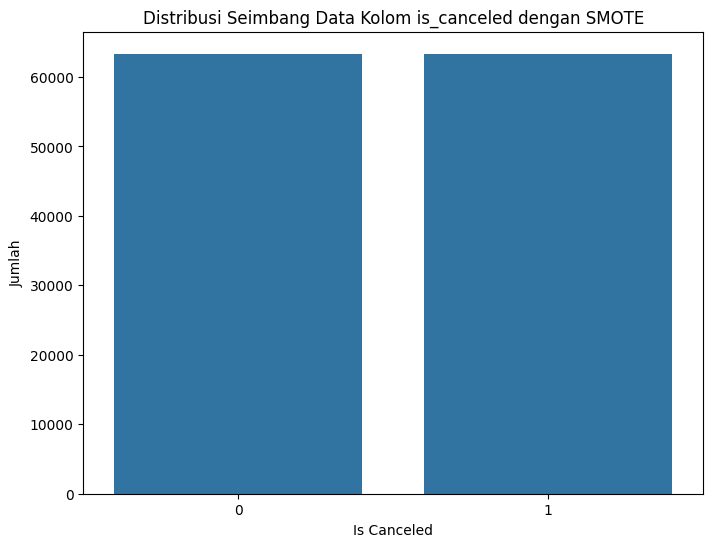

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Menangani nilai yang hilang
threshold = len(data) * 0.5
data_cleaned = data.dropna(thresh=threshold, axis=1)
numerical_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)
data_cleaned = data_cleaned.drop_duplicates()

# Mengonversi variabel kategorikal menjadi numerik menggunakan one-hot encoding
categorical_columns = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'country']
data_transformed = pd.get_dummies(data_cleaned, columns=categorical_columns)

# Konversi kolom tanggal menjadi numerik (misalnya: timestamp)
data_transformed['reservation_status_date'] = pd.to_datetime(data_transformed['reservation_status_date']).astype(int) / 10**9

# Menormalisasi fitur numerik
scaler = MinMaxScaler()
numerical_features = ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status_date']
data_normalized = data_transformed.copy()
data_normalized[numerical_features] = scaler.fit_transform(data_normalized[numerical_features])

# Mengonversi target is_canceled menjadi numerik
label_encoder_is_canceled = LabelEncoder()
data_normalized['is_canceled'] = label_encoder_is_canceled.fit_transform(data_normalized['is_canceled'])

# Mengonversi target reservation_status menjadi numerik
label_encoder_reservation_status = LabelEncoder()
data_normalized['reservation_status'] = label_encoder_reservation_status.fit_transform(data_cleaned['reservation_status'])

# Resampling menggunakan SMOTE untuk kolom is_canceled
X_is_canceled = data_normalized.drop(columns=['is_canceled'])
y_is_canceled = data_normalized['is_canceled']

smote_is_canceled = SMOTE(random_state=42)
X_resampled_is_canceled, y_resampled_is_canceled = smote_is_canceled.fit_resample(X_is_canceled, y_is_canceled)

# Menggabungkan kembali data yang diseimbangkan
data_balanced_is_canceled = X_resampled_is_canceled.copy()
data_balanced_is_canceled['is_canceled'] = y_resampled_is_canceled

# Distribusi data yang seimbang kolom is_canceled
plt.figure(figsize=(8, 6))
sns.countplot(x='is_canceled', data=data_balanced_is_canceled)
plt.title('Distribusi Seimbang Data Kolom is_canceled dengan SMOTE')
plt.xlabel('Is Canceled')
plt.ylabel('Jumlah')
plt.show()


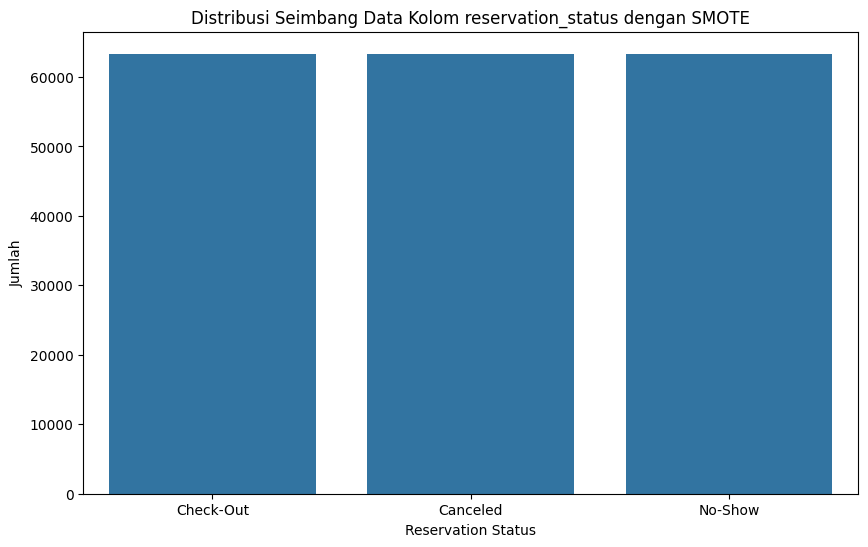

In [ ]:
# Resampling menggunakan SMOTE untuk kolom reservation_status
X_reservation_status = data_normalized.drop(columns=['reservation_status'])
y_reservation_status = data_normalized['reservation_status']

smote_reservation_status = SMOTE(random_state=42)
X_resampled_reservation_status, y_resampled_reservation_status = smote_reservation_status.fit_resample(X_reservation_status, y_reservation_status)

# Mengonversi target kembali ke bentuk kategorikal
data_balanced_reservation_status = X_resampled_reservation_status.copy()
data_balanced_reservation_status['reservation_status'] = label_encoder_reservation_status.inverse_transform(y_resampled_reservation_status)

# Distribusi data yang seimbang kolom reservation_status
plt.figure(figsize=(10, 6))
sns.countplot(x='reservation_status', data=data_balanced_reservation_status, order=data_balanced_reservation_status['reservation_status'].value_counts().index)
plt.title('Distribusi Seimbang Data Kolom reservation_status dengan SMOTE')
plt.xlabel('Reservation Status')
plt.ylabel('Jumlah')
plt.show()


**<h2>Algoritma Yang Digunakan pada kolom is_canceled & reservation_status (Sudah di Resampled)**<h2>

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Menangani nilai yang hilang
threshold = len(data) * 0.5
data_cleaned = data.dropna(thresh=threshold, axis=1)
numerical_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)
data_cleaned = data_cleaned.drop_duplicates()

# Mengonversi variabel kategorikal menjadi numerik menggunakan one-hot encoding
categorical_columns = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'country']
data_transformed = pd.get_dummies(data_cleaned, columns=categorical_columns)

# Konversi kolom tanggal menjadi numerik (misalnya: timestamp)
data_transformed['reservation_status_date'] = pd.to_datetime(data_transformed['reservation_status_date']).astype(int) / 10**9

# Menghapus kolom 'reservation_status' karena berisi string
data_transformed = data_transformed.drop(columns=['reservation_status'])

# Menormalisasi fitur numerik
scaler = MinMaxScaler()
numerical_features = ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status_date']
data_normalized = data_transformed.copy()
data_normalized[numerical_features] = scaler.fit_transform(data_normalized[numerical_features])

# Mengonversi target is_canceled menjadi numerik
label_encoder_is_canceled = LabelEncoder()
data_normalized['is_canceled'] = label_encoder_is_canceled.fit_transform(data_normalized['is_canceled'])

# Resampling menggunakan SMOTE untuk kolom is_canceled
X = data_normalized.drop(columns=['is_canceled'])
y = data_normalized['is_canceled']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


<ipython-input-33-a547cd3550f3>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
<ipython-input-33-a547cd3550f3>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


is_canceled

Naive Baiyes

Naive Bayes Accuracy: 0.5986424089348436
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

           0       0.56      0.92      0.70     12705
           1       0.78      0.27      0.40     12634

    accuracy                           0.60     25339
   macro avg       0.67      0.60      0.55     25339
weighted avg       0.67      0.60      0.55     25339



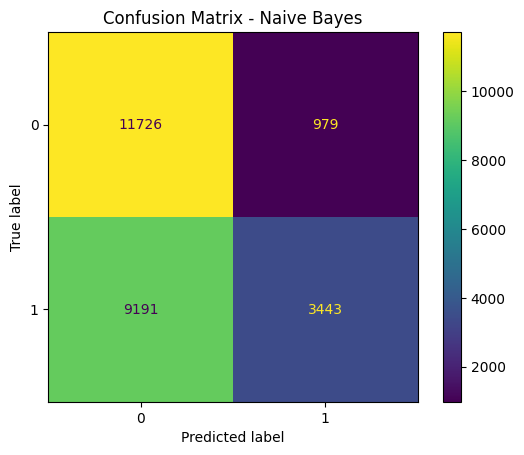

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Melatih model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Memprediksi
y_pred_nb = nb_model.predict(X_test)

# Accuracy dan Classification Report
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder_is_canceled.classes_.astype(str)))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=label_encoder_is_canceled.classes_.astype(str))
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()


Decision Tree

Decision Tree Accuracy: 0.9232408540194956
Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     12705
           1       0.92      0.92      0.92     12634

    accuracy                           0.92     25339
   macro avg       0.92      0.92      0.92     25339
weighted avg       0.92      0.92      0.92     25339



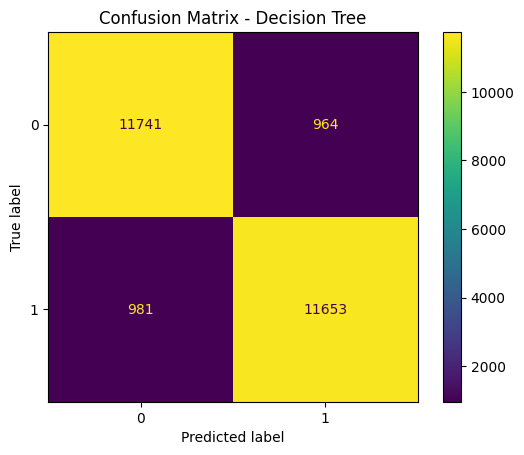

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Melatih model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Memprediksi
y_pred_dt = dt_model.predict(X_test)

# Accuracy dan Classification Report
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder_is_canceled.classes_.astype(str)))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=label_encoder_is_canceled.classes_.astype(str))
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()



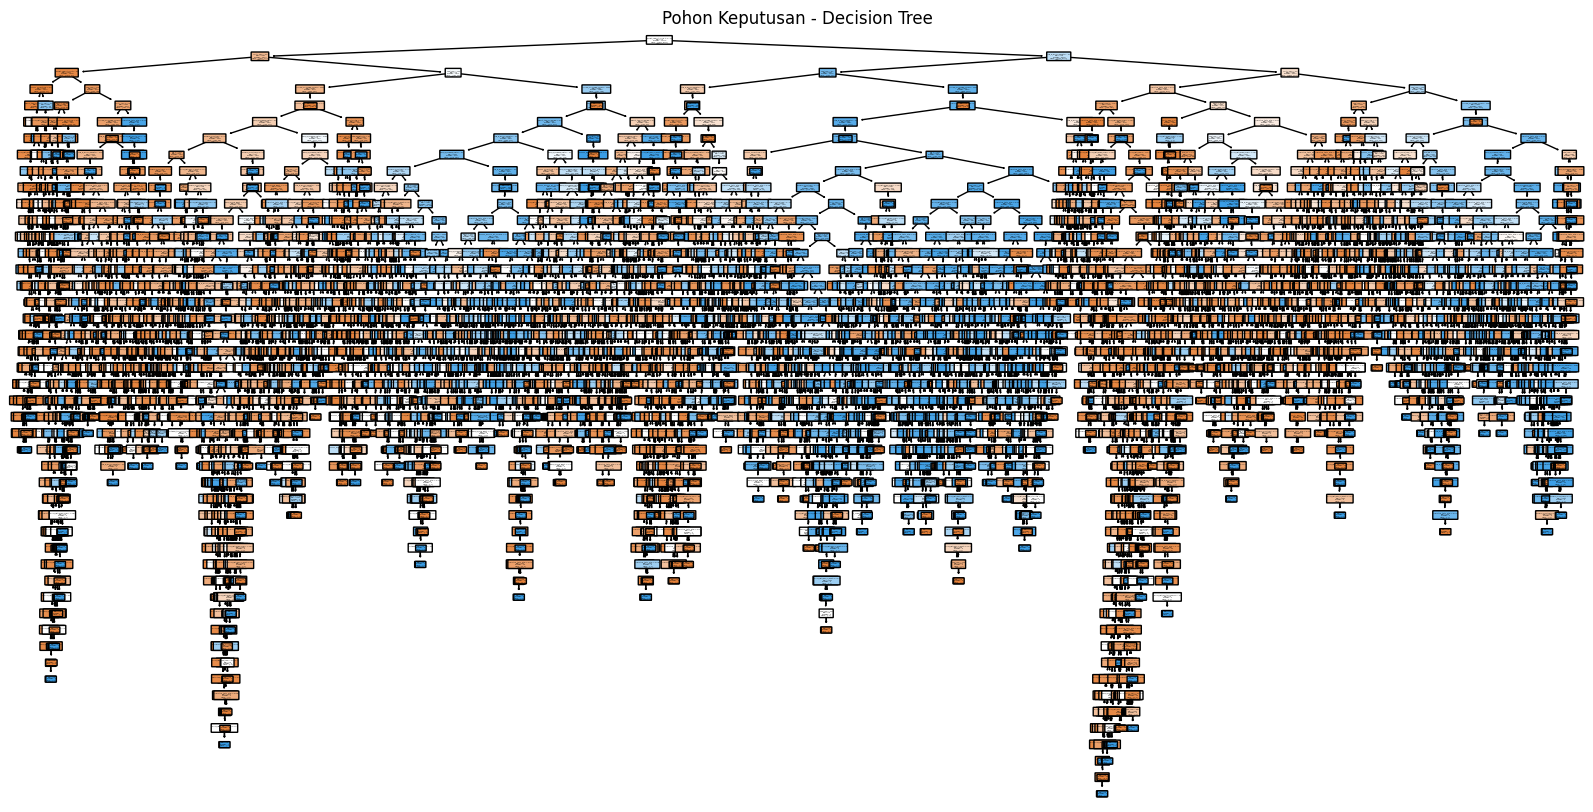

In [ ]:
# Visualisasi pohon keputusan
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=label_encoder_is_canceled.classes_.astype(str), filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()


Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8078061486246497
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81     12705
           1       0.82      0.79      0.80     12634

    accuracy                           0.81     25339
   macro avg       0.81      0.81      0.81     25339
weighted avg       0.81      0.81      0.81     25339



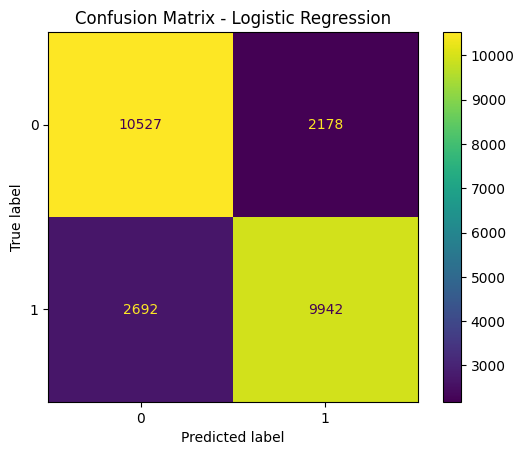

In [ ]:
from sklearn.linear_model import LogisticRegression

# Melatih model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Memprediksi
y_pred_lr = lr_model.predict(X_test)

# Accuracy dan Classification Report
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder_is_canceled.classes_.astype(str)))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=label_encoder_is_canceled.classes_.astype(str))
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


Random Forest

Random Forest Accuracy: 0.9364615809621532
Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94     12705
           1       0.95      0.92      0.94     12634

    accuracy                           0.94     25339
   macro avg       0.94      0.94      0.94     25339
weighted avg       0.94      0.94      0.94     25339



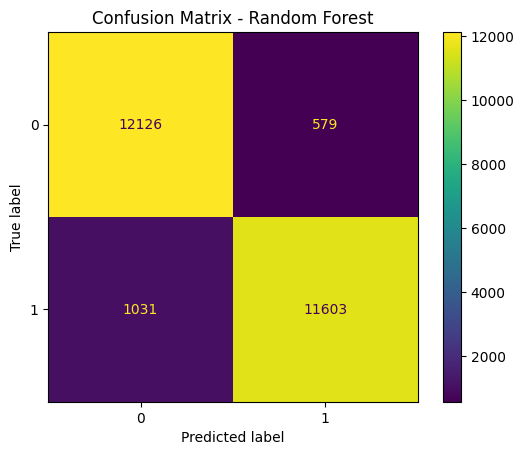

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Melatih model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Memprediksi
y_pred_rf = rf_model.predict(X_test)

# Accuracy dan Classification Report
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder_is_canceled.classes_.astype(str)))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder_is_canceled.classes_.astype(str))
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()


XGBoost

XGBoost Accuracy: 0.9723746004183275
Classification Report - XGBoost:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     12705
           1       0.99      0.95      0.97     12634

    accuracy                           0.97     25339
   macro avg       0.97      0.97      0.97     25339
weighted avg       0.97      0.97      0.97     25339



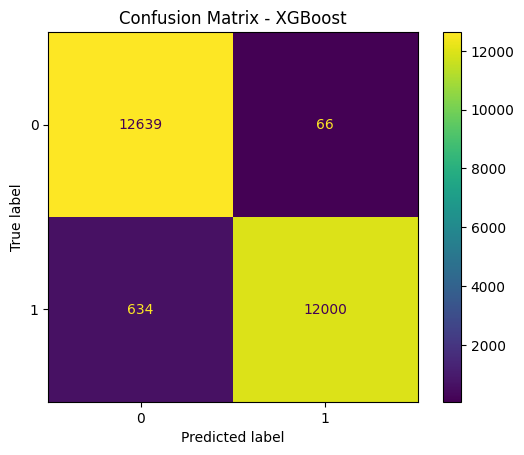

In [ ]:
import xgboost as xgb

# Melatih model
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Memprediksi
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy dan Classification Report
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder_is_canceled.classes_.astype(str)))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=label_encoder_is_canceled.classes_.astype(str))
disp_xgb.plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()


reservation_status

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Menangani nilai yang hilang
threshold = len(data) * 0.5
data_cleaned = data.dropna(thresh=threshold, axis=1)
numerical_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)
data_cleaned = data_cleaned.drop_duplicates()

# Mengonversi variabel kategorikal menjadi numerik menggunakan one-hot encoding
categorical_columns = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'country']
data_transformed = pd.get_dummies(data_cleaned, columns=categorical_columns)

# Konversi kolom tanggal menjadi numerik (misalnya: timestamp)
data_transformed['reservation_status_date'] = pd.to_datetime(data_transformed['reservation_status_date']).astype(int) / 10**9

# Menormalisasi fitur numerik
scaler = MinMaxScaler()
numerical_features = ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status_date']
data_normalized = data_transformed.copy()
data_normalized[numerical_features] = scaler.fit_transform(data_normalized[numerical_features])

# Mengonversi target reservation_status menjadi numerik
label_encoder_reservation_status = LabelEncoder()
data_normalized['reservation_status'] = label_encoder_reservation_status.fit_transform(data_cleaned['reservation_status'])

# Resampling menggunakan SMOTE untuk kolom reservation_status
X = data_normalized.drop(columns=['reservation_status'])
y = data_normalized['reservation_status']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


<ipython-input-40-f9ca31bb17c0>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
<ipython-input-40-f9ca31bb17c0>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


Naive Baiyes

Naive Bayes Accuracy: 0.7135866133445591
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

    Canceled       0.96      0.14      0.24     12532
   Check-Out       1.00      1.00      1.00     12755
     No-Show       0.54      0.99      0.70     12721

    accuracy                           0.71     38008
   macro avg       0.83      0.71      0.65     38008
weighted avg       0.83      0.71      0.65     38008



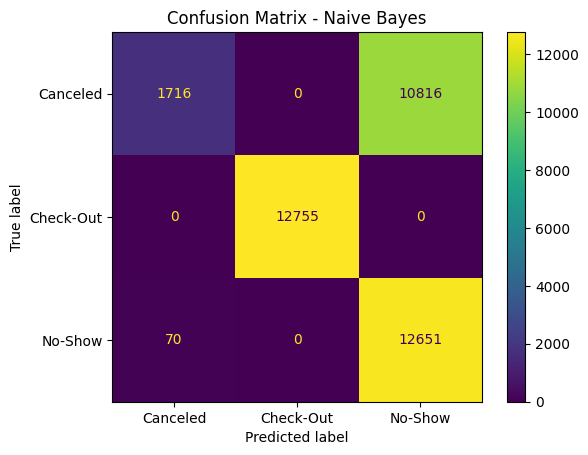

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Melatih model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Memprediksi
y_pred_nb = nb_model.predict(X_test)

# Accuracy dan Classification Report
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder_reservation_status.classes_.astype(str)))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=label_encoder_reservation_status.classes_.astype(str))
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()


Decision Tree

Decision Tree Accuracy: 0.9842138497158492
Classification Report - Decision Tree:
              precision    recall  f1-score   support

    Canceled       0.98      0.97      0.98     12532
   Check-Out       1.00      1.00      1.00     12755
     No-Show       0.97      0.99      0.98     12721

    accuracy                           0.98     38008
   macro avg       0.98      0.98      0.98     38008
weighted avg       0.98      0.98      0.98     38008



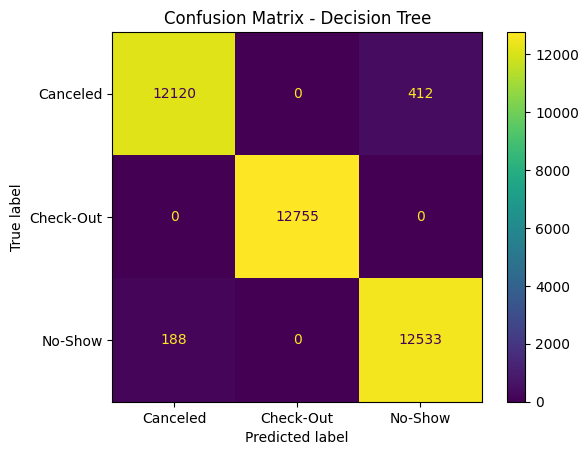

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Melatih model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Memprediksi
y_pred_dt = dt_model.predict(X_test)

# Accuracy dan Classification Report
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder_reservation_status.classes_.astype(str)))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=label_encoder_reservation_status.classes_.astype(str))
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()


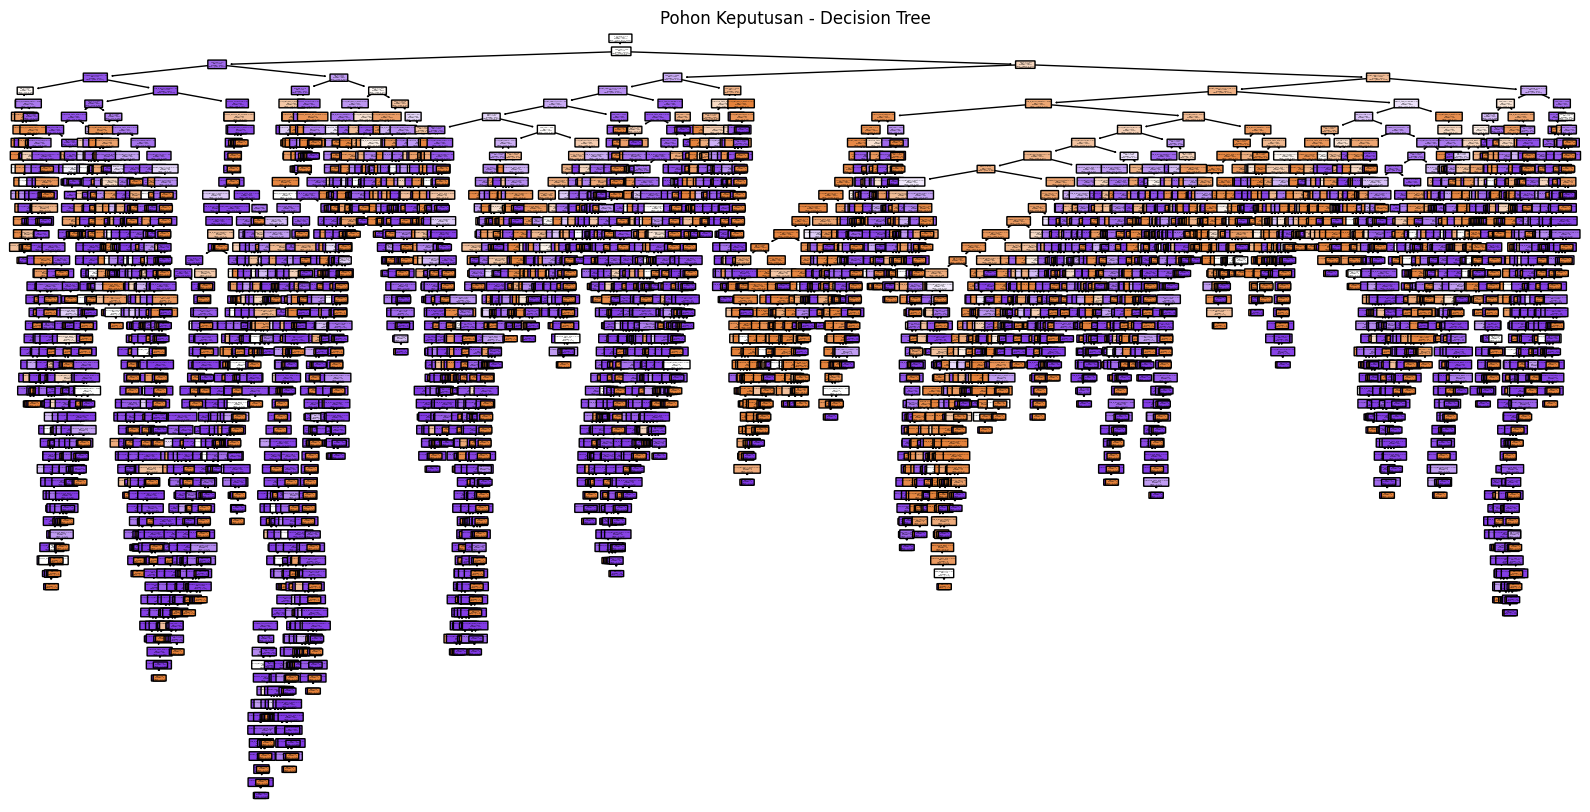

In [ ]:
# Visualisasi pohon keputusan
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=label_encoder_reservation_status.classes_.astype(str), filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()

Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.843717112186908
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

    Canceled       0.76      0.77      0.77     12532
   Check-Out       0.99      1.00      0.99     12755
     No-Show       0.78      0.76      0.77     12721

    accuracy                           0.84     38008
   macro avg       0.84      0.84      0.84     38008
weighted avg       0.84      0.84      0.84     38008



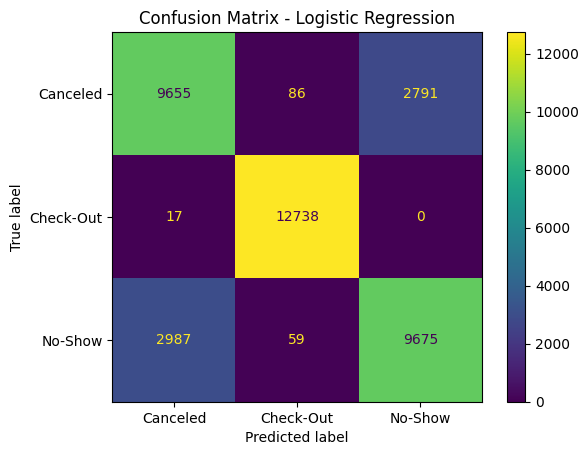

In [ ]:
from sklearn.linear_model import LogisticRegression

# Melatih model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Memprediksi
y_pred_lr = lr_model.predict(X_test)

# Accuracy dan Classification Report
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder_reservation_status.classes_.astype(str)))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=label_encoder_reservation_status.classes_.astype(str))
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


Random Forest

Random Forest Accuracy: 0.9951326036623869
Classification Report - Random Forest:
              precision    recall  f1-score   support

    Canceled       0.99      0.99      0.99     12532
   Check-Out       1.00      1.00      1.00     12755
     No-Show       0.99      0.99      0.99     12721

    accuracy                           1.00     38008
   macro avg       1.00      1.00      1.00     38008
weighted avg       1.00      1.00      1.00     38008



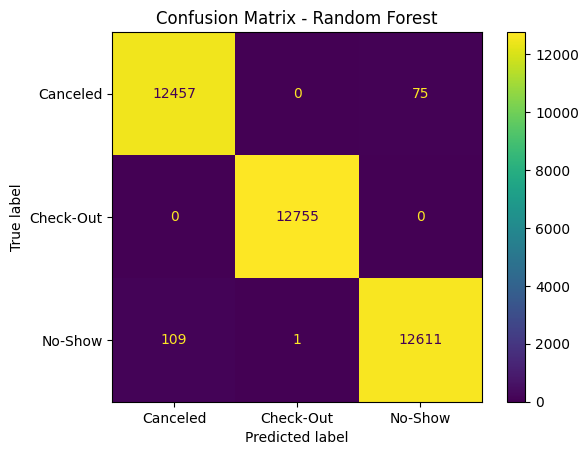

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Melatih model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Memprediksi
y_pred_rf = rf_model.predict(X_test)

# Accuracy dan Classification Report
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder_reservation_status.classes_.astype(str)))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder_reservation_status.classes_.astype(str))
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()


XGBoost

XGBoost Accuracy: 0.980872447905704
Classification Report - XGBoost:
              precision    recall  f1-score   support

    Canceled       0.99      0.95      0.97     12532
   Check-Out       1.00      1.00      1.00     12755
     No-Show       0.96      0.99      0.97     12721

    accuracy                           0.98     38008
   macro avg       0.98      0.98      0.98     38008
weighted avg       0.98      0.98      0.98     38008



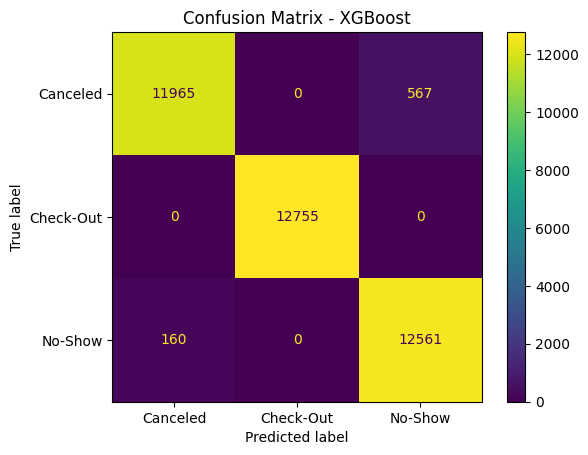

In [ ]:
import xgboost as xgb

# Melatih model
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Memprediksi
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy dan Classification Report
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder_reservation_status.classes_.astype(str)))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=label_encoder_reservation_status.classes_.astype(str))
disp_xgb.plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()


**<h2>Seleksi Fitur<h2>**

Chi-square

In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Menangani nilai yang hilang
threshold = len(data) * 0.5
data_cleaned = data.dropna(thresh=threshold, axis=1)
numerical_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)
data_cleaned = data_cleaned.drop_duplicates()

# Mengonversi variabel kategorikal menjadi numerik menggunakan one-hot encoding
categorical_columns = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'country']
data_transformed = pd.get_dummies(data_cleaned, columns=categorical_columns)

# Konversi kolom tanggal menjadi numerik (misalnya: timestamp)
data_transformed['reservation_status_date'] = pd.to_datetime(data_transformed['reservation_status_date']).astype(int) / 10**9

# Menormalisasi fitur numerik
scaler = MinMaxScaler()
numerical_features = ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status_date']
data_normalized = data_transformed.copy()
data_normalized[numerical_features] = scaler.fit_transform(data_normalized[numerical_features])

# Mengonversi target menjadi numerik untuk kolom is_canceled
label_encoder_is_canceled = LabelEncoder()
data_normalized['is_canceled'] = label_encoder_is_canceled.fit_transform(data_normalized['is_canceled'])

# Mengonversi target menjadi numerik untuk kolom reservation_status
label_encoder_reservation_status = LabelEncoder()
data_normalized['reservation_status'] = label_encoder_reservation_status.fit_transform(data_cleaned['reservation_status'])

# Menggunakan chi-square untuk seleksi fitur
# Ganti 'reservation_status' dengan 'is_canceled' jika diperlukan
X = data_normalized.drop(columns=['reservation_status'])  # Ubah ini menjadi 'is_canceled' jika perlu
y = data_normalized['reservation_status']  # Ubah ini menjadi 'is_canceled' jika perlu

# Menggunakan SelectKBest untuk memilih 10 fitur terbaik berdasarkan chi-square
chi2_selector = SelectKBest(chi2, k=10)
X_kbest = chi2_selector.fit_transform(X, y)

# Mendapatkan fitur terpilih
selected_features = X.columns[chi2_selector.get_support()]

print("Fitur terpilih:", selected_features)


<ipython-input-47-e77c49d2ad4e>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mean(), inplace=True)
<ipython-input-47-e77c49d2ad4e>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


Fitur terpilih: Index(['is_canceled', 'lead_time', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent',
       'days_in_waiting_list', 'market_segment_Offline TA/TO',
       'market_segment_Online TA', 'deposit_type_Non Refund'],
      dtype='object')


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

# Memilih fitur yang akan digunakan
features = ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list', 'previous_bookings_not_canceled']
X_selected = X_resampled[features]

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_resampled, test_size=0.2, random_state=42)

# Menggunakan chi-square untuk seleksi fitur
chi2_selector = SelectKBest(chi2, k='all')
X_kbest = chi2_selector.fit_transform(X_train, y_train)

# Mendapatkan fitur terpilih
selected_features = [features[i] for i in chi2_selector.get_support(indices=True)]
print(f"Selected features: {selected_features}")

# Menampilkan skor chi-square
chi2_scores = chi2_selector.scores_
sorted_features = sorted(zip(features, chi2_scores), key=lambda x: x[1], reverse=True)
for i, (feature, score) in enumerate(sorted_features, 1):
    print(f"Step {i}:")
    print(f"Feature: {feature}")
    print(f"Chi-Square Score: {score}")


Selected features: ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list', 'previous_bookings_not_canceled']
Step 1:
Feature: lead_time
Chi-Square Score: 1072593.4962994803
Step 2:
Feature: agent
Chi-Square Score: 103470.68288226887
Step 3:
Feature: is_canceled
Chi-Square Score: 50591.00000002522
Step 4:
Feature: days_in_waiting_list
Chi-Square Score: 38769.36727035953
Step 5:
Feature: previous_bookings_not_canceled
Chi-Square Score: 12241.439616503312


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np

# Memilih fitur yang akan digunakan
features = ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list', 'previous_bookings_not_canceled']
X_selected = X_resampled[features]

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_resampled, test_size=0.2, random_state=42)

# Menggunakan chi-square untuk seleksi fitur
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_train, y_train)

# Mendapatkan fitur terpilih
selected_features = [features[i] for i in chi2_selector.get_support(indices=True)]
print(f"Selected features: {selected_features}")

# Menampilkan skor chi-square
chi2_scores = chi2_selector.scores_
sorted_features = sorted(zip(features, chi2_scores), key=lambda x: x[1], reverse=True)

# Menampilkan fitur dan skor pada setiap langkah
for i, (feature, score) in enumerate(sorted_features, 1):
    print(f"Step {i}:")
    print(f"Feature: {feature}")
    print(f"Chi-Square Score: {score}")


Selected features: ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list', 'previous_bookings_not_canceled']
Step 1:
Feature: lead_time
Chi-Square Score: 1072593.4962994803
Step 2:
Feature: agent
Chi-Square Score: 103470.68288226887
Step 3:
Feature: is_canceled
Chi-Square Score: 50591.00000002522
Step 4:
Feature: days_in_waiting_list
Chi-Square Score: 38769.36727035953
Step 5:
Feature: previous_bookings_not_canceled
Chi-Square Score: 12241.439616503312


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Memilih fitur yang akan digunakan
features = ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list', 'previous_bookings_not_canceled']
X_selected = X_resampled[features]

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_resampled, test_size=0.2, random_state=42)

# Menggunakan chi-square untuk seleksi fitur
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_train, y_train)

# Mendapatkan skor chi-square
chi2_scores = chi2_selector.scores_
sorted_features = sorted(zip(features, chi2_scores), key=lambda x: x[1], reverse=True)

# Melakukan evaluasi dengan menambahkan fitur secara bertahap
selected_features = []
for i in range(1, len(sorted_features) + 1):
    step_features = [f[0] for f in sorted_features[:i]]
    X_train_step = X_train[step_features]
    model = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(model, X_train_step, y_train, cv=5, scoring='accuracy')
    avg_score = np.mean(scores)
    selected_features.append((step_features, avg_score))

# Menampilkan hasil
for i, (features, score) in enumerate(selected_features, 1):
    print(f"Step {i}:")
    print(f"Features: {features}")
    print(f"CV Score: {score}")


Step 1:
Features: ['lead_time']
CV Score: 0.4229954614220877
Step 2:
Features: ['lead_time', 'agent']
CV Score: 0.43005327895810036
Step 3:
Features: ['lead_time', 'agent', 'is_canceled']
CV Score: 0.7582450832072618
Step 4:
Features: ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list']
CV Score: 0.7580148654870749
Step 5:
Features: ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list', 'previous_bookings_not_canceled']
CV Score: 0.7582253502598171


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

# Menggunakan fitur is_canceled
X_selected = X_resampled[['is_canceled']]
y = y_resampled

# Menggunakan chi-square untuk seleksi fitur
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_selected, y)

# Mendapatkan skor chi-square
chi2_score = chi2_selector.scores_[0]
print(f"Chi-Square Score untuk is_canceled: {chi2_score}")


Chi-Square Score untuk is_canceled: 63346.0000000617


In [ ]:
# Menggunakan fitur lead_time
X_selected = X_resampled[['lead_time']]
y = y_resampled

# Menggunakan chi-square untuk seleksi fitur
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_selected, y)

# Mendapatkan skor chi-square
chi2_score = chi2_selector.scores_[0]
print(f"Chi-Square Score untuk lead_time: {chi2_score}")


Chi-Square Score untuk lead_time: 1333438.8392354574


In [ ]:
# Menggunakan fitur previous_bookings_not_canceled
X_selected = X_resampled[['previous_bookings_not_canceled']]
y = y_resampled

# Menggunakan chi-square untuk seleksi fitur
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_selected, y)

# Mendapatkan skor chi-square
chi2_score = chi2_selector.scores_[0]
print(f"Chi-Square Score untuk previous_bookings_not_canceled: {chi2_score}")


Chi-Square Score untuk previous_bookings_not_canceled: 14938.196733778317


In [ ]:
# Menggunakan fitur agent
X_selected = X_resampled[['agent']]
y = y_resampled

# Menggunakan chi-square untuk seleksi fitur
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_selected, y)

# Mendapatkan skor chi-square
chi2_score = chi2_selector.scores_[0]
print(f"Chi-Square Score untuk agent: {chi2_score}")


Chi-Square Score untuk agent: 125151.65160795089


In [ ]:
# Menggunakan fitur days_in_waiting_list
X_selected = X_resampled[['days_in_waiting_list']]
y = y_resampled

# Menggunakan chi-square untuk seleksi fitur
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_selected, y)

# Mendapatkan skor chi-square
chi2_score = chi2_selector.scores_[0]
print(f"Chi-Square Score untuk days_in_waiting_list: {chi2_score}")


Chi-Square Score untuk days_in_waiting_list: 47544.58896538887


<h2>Algoritma untuk is_canceled<h2>

Naive Bayes Accuracy: 0.6653073037255315
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

           0       0.50      1.00      0.66     12532
           1       1.00      1.00      1.00     12755
           2       0.00      0.00      0.00     12721

    accuracy                           0.67     38008
   macro avg       0.50      0.67      0.55     38008
weighted avg       0.50      0.67      0.55     38008



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


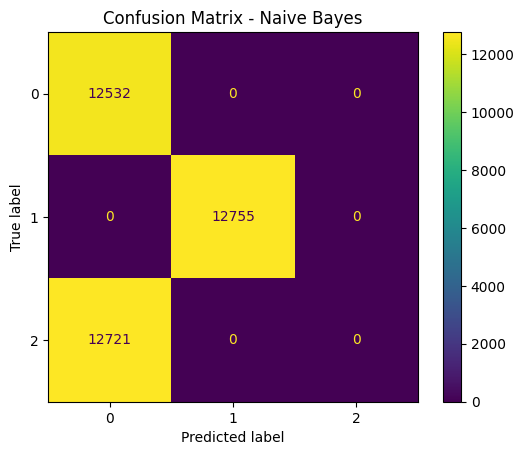

Decision Tree Accuracy: 0.6653073037255315
Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       0.50      1.00      0.66     12532
           1       1.00      1.00      1.00     12755
           2       0.00      0.00      0.00     12721

    accuracy                           0.67     38008
   macro avg       0.50      0.67      0.55     38008
weighted avg       0.50      0.67      0.55     38008



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


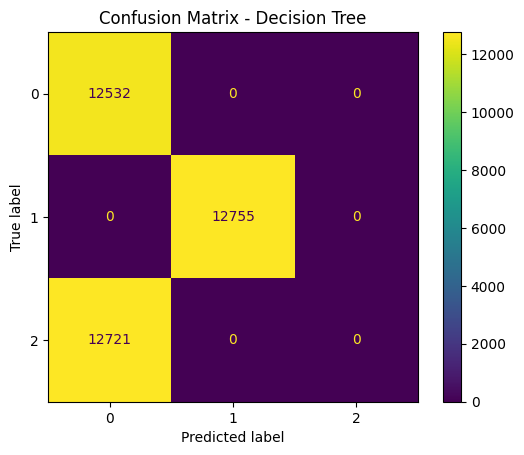

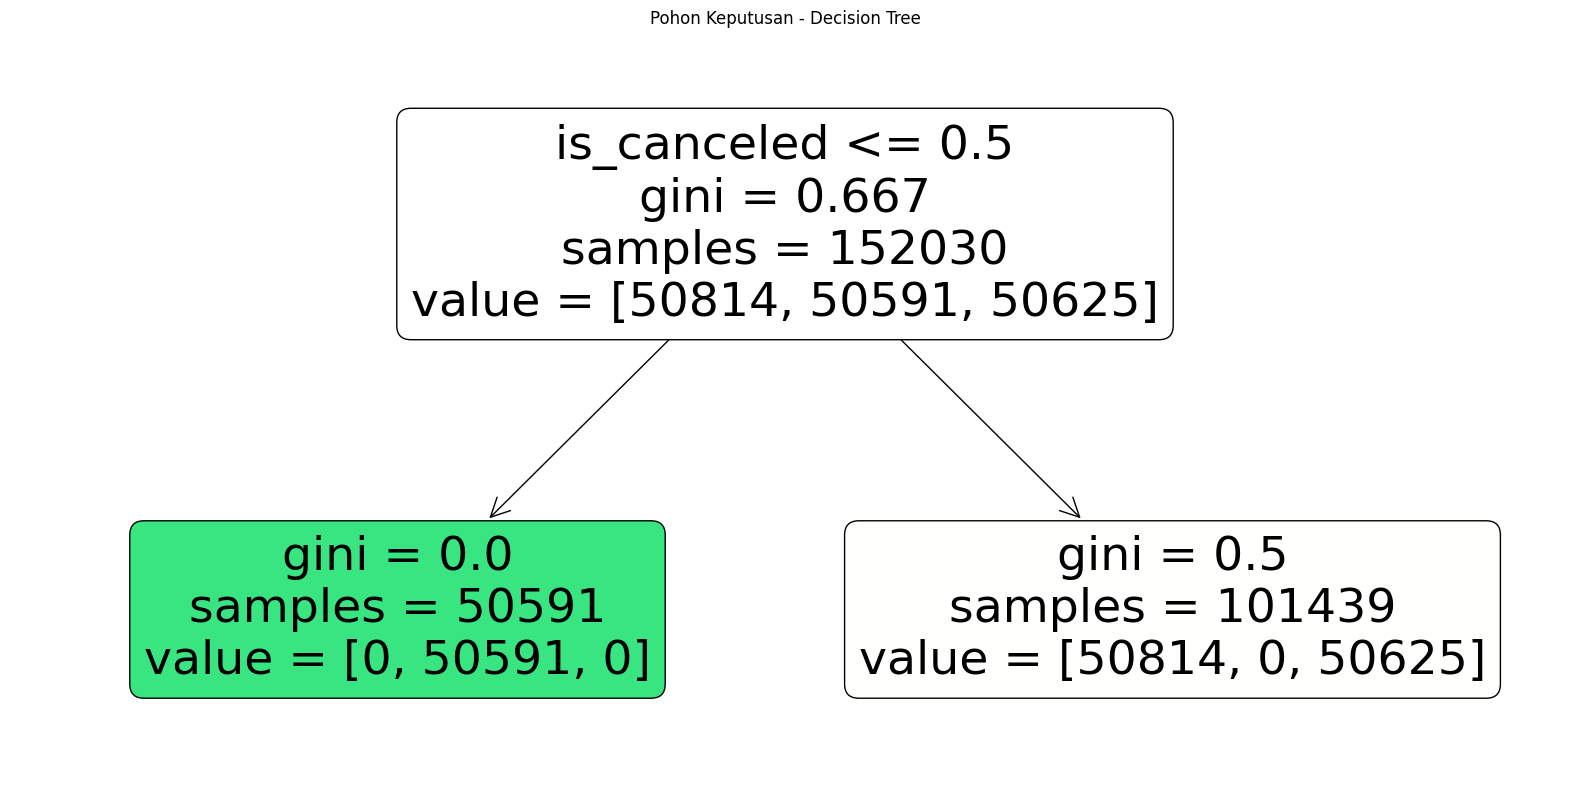

Logistic Regression Accuracy: 0.6653073037255315
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.50      1.00      0.66     12532
           1       1.00      1.00      1.00     12755
           2       0.00      0.00      0.00     12721

    accuracy                           0.67     38008
   macro avg       0.50      0.67      0.55     38008
weighted avg       0.50      0.67      0.55     38008



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


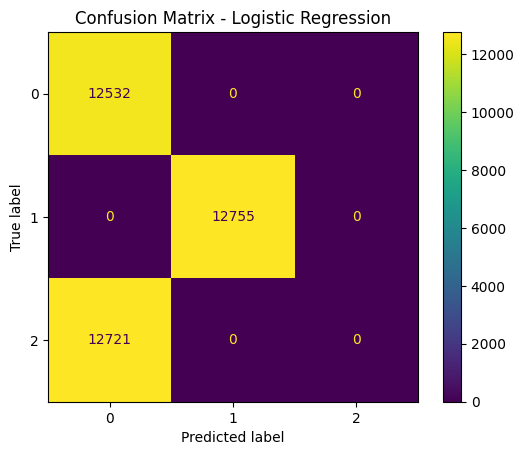

Random Forest Accuracy: 0.6653073037255315
Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.50      1.00      0.66     12532
           1       1.00      1.00      1.00     12755
           2       0.00      0.00      0.00     12721

    accuracy                           0.67     38008
   macro avg       0.50      0.67      0.55     38008
weighted avg       0.50      0.67      0.55     38008



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


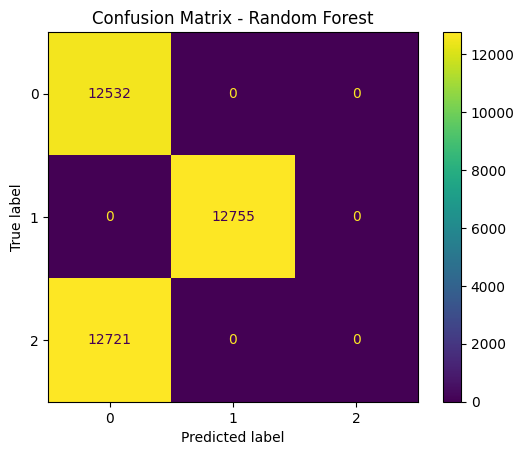

XGBoost Accuracy: 0.6653073037255315
Classification Report - XGBoost:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.50      1.00      0.66     12532
           1       1.00      1.00      1.00     12755
           2       0.00      0.00      0.00     12721

    accuracy                           0.67     38008
   macro avg       0.50      0.67      0.55     38008
weighted avg       0.50      0.67      0.55     38008



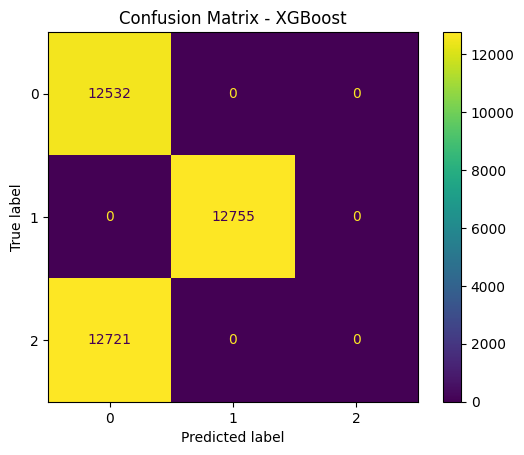

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Menggunakan fitur is_canceled
X_selected = X_resampled[['is_canceled']]
y = y_resampled

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=['is_canceled'], filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()

# XGBoost
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()


<h2>Algoritma untuk lead_time<h2>

Naive Bayes Accuracy: 0.40317827825720903
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

           0       0.47      0.39      0.43     12532
           1       0.29      0.02      0.03     12755
           2       0.38      0.81      0.52     12721

    accuracy                           0.40     38008
   macro avg       0.38      0.40      0.33     38008
weighted avg       0.38      0.40      0.32     38008



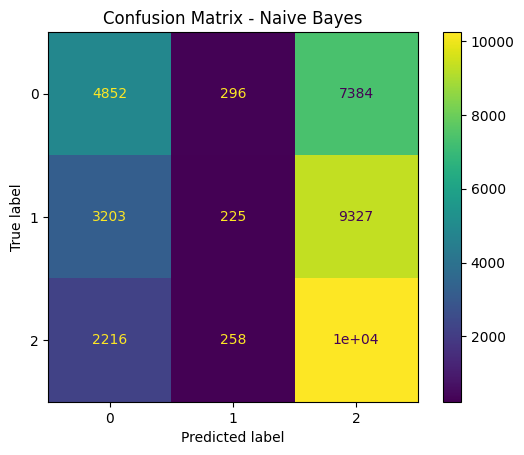

Decision Tree Accuracy: 0.4529835824037045
Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       0.46      0.68      0.55     12532
           1       0.40      0.12      0.18     12755
           2       0.46      0.56      0.51     12721

    accuracy                           0.45     38008
   macro avg       0.44      0.45      0.41     38008
weighted avg       0.44      0.45      0.41     38008



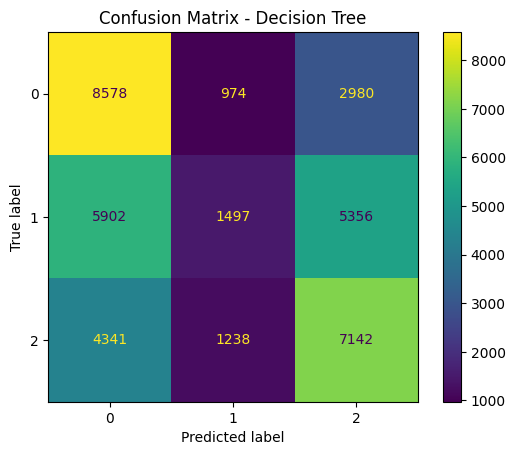

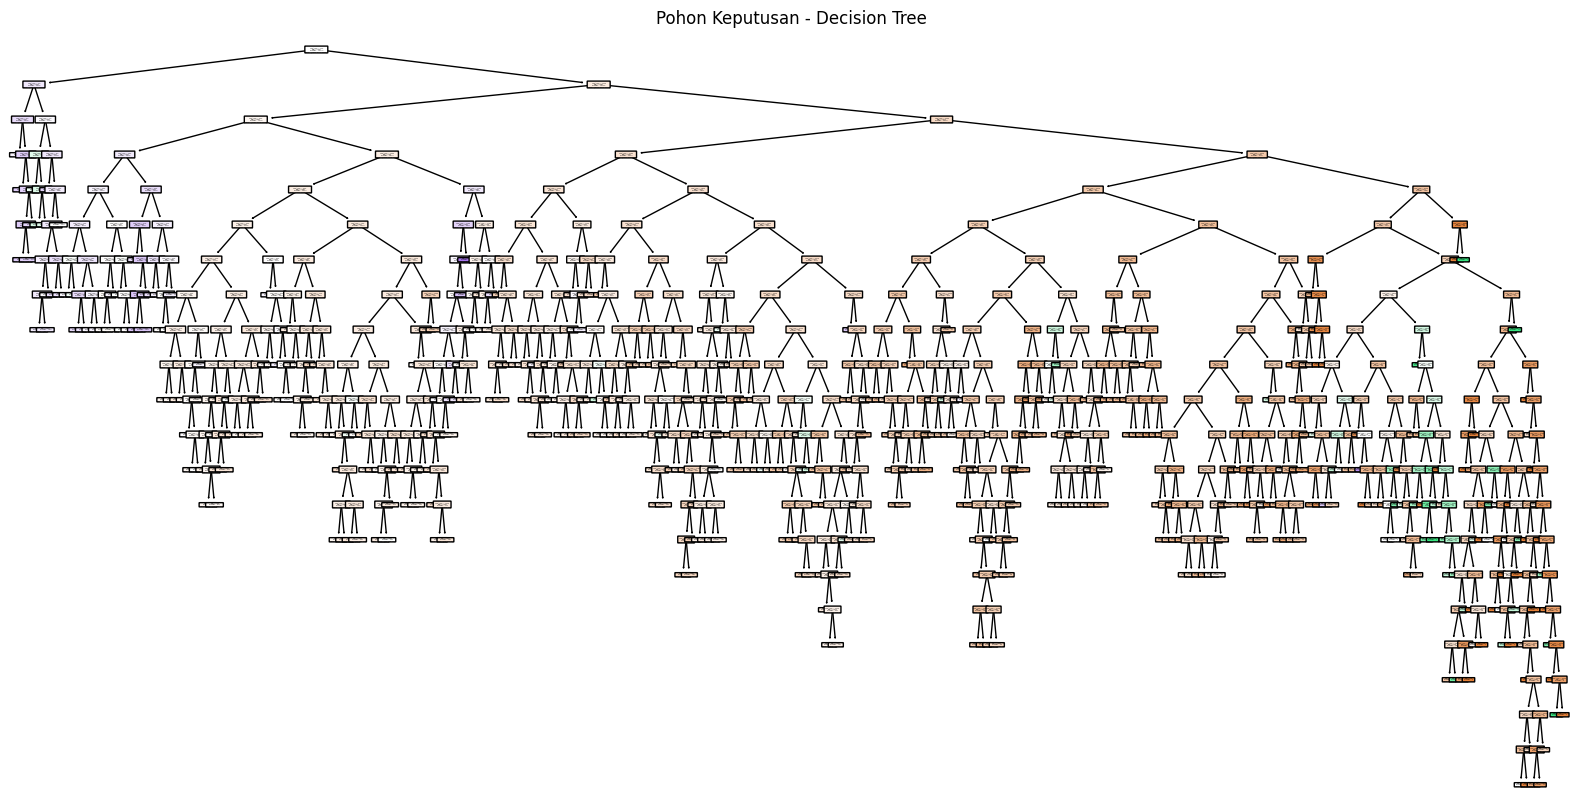

Logistic Regression Accuracy: 0.42193748684487475
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.46      0.48      0.47     12532
           1       0.32      0.08      0.13     12755
           2       0.41      0.70      0.52     12721

    accuracy                           0.42     38008
   macro avg       0.40      0.42      0.37     38008
weighted avg       0.40      0.42      0.37     38008



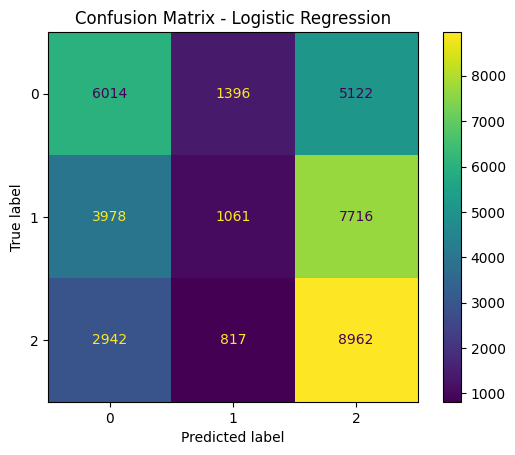

Random Forest Accuracy: 0.4534834771627026
Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.46      0.68      0.55     12532
           1       0.41      0.11      0.18     12755
           2       0.46      0.57      0.51     12721

    accuracy                           0.45     38008
   macro avg       0.44      0.45      0.41     38008
weighted avg       0.44      0.45      0.41     38008



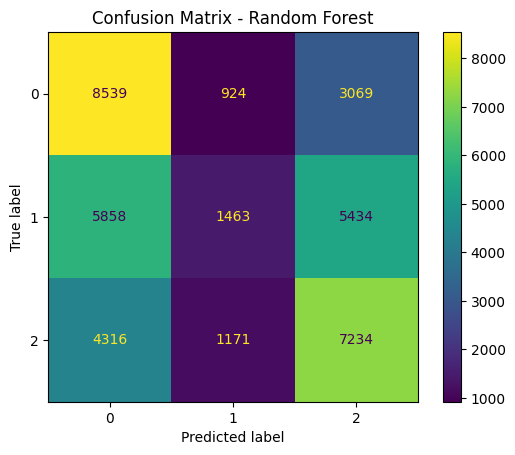

XGBoost Accuracy: 0.4510892443696064
Classification Report - XGBoost:
              precision    recall  f1-score   support

           0       0.45      0.70      0.55     12532
           1       0.40      0.09      0.14     12755
           2       0.46      0.57      0.51     12721

    accuracy                           0.45     38008
   macro avg       0.44      0.45      0.40     38008
weighted avg       0.44      0.45      0.40     38008



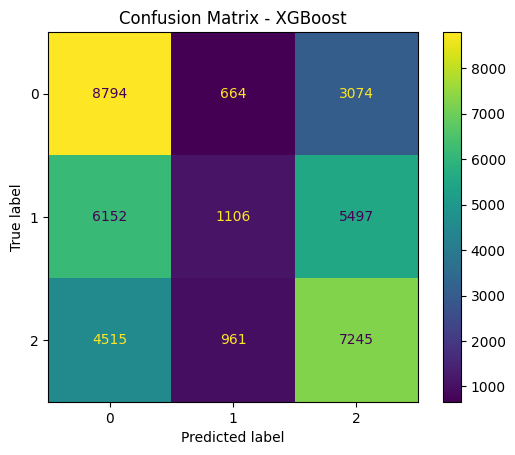

In [ ]:
# Menggunakan fitur lead_time
X_selected = X_resampled[['lead_time']]
y = y_resampled

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=['lead_time'], filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()

# XGBoost
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()


<h2>Algoritma untuk previous_cancellations<h2>

Naive Bayes Accuracy: 0.3447432119553778
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

           0       0.77      0.03      0.06     12532
           1       0.00      0.00      0.00     12755
           2       0.34      1.00      0.51     12721

    accuracy                           0.34     38008
   macro avg       0.37      0.34      0.19     38008
weighted avg       0.37      0.34      0.19     38008



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


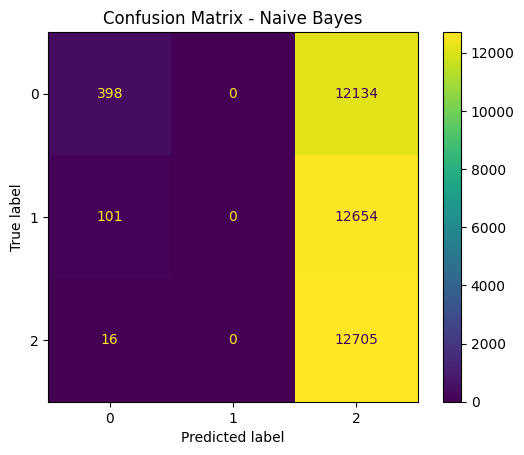

Decision Tree Accuracy: 0.34526941696484953
Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       0.84      0.03      0.06     12532
           1       0.61      0.00      0.01     12755
           2       0.34      1.00      0.51     12721

    accuracy                           0.35     38008
   macro avg       0.60      0.34      0.19     38008
weighted avg       0.59      0.35      0.19     38008



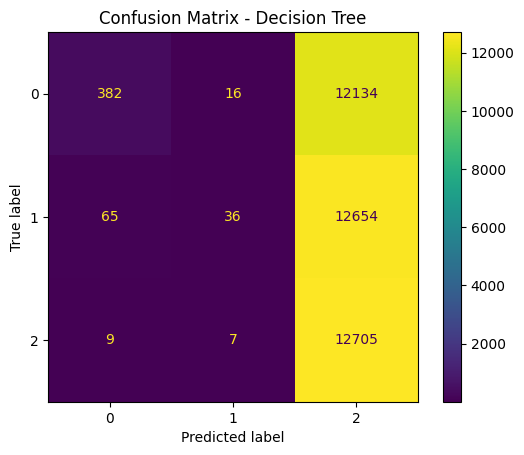

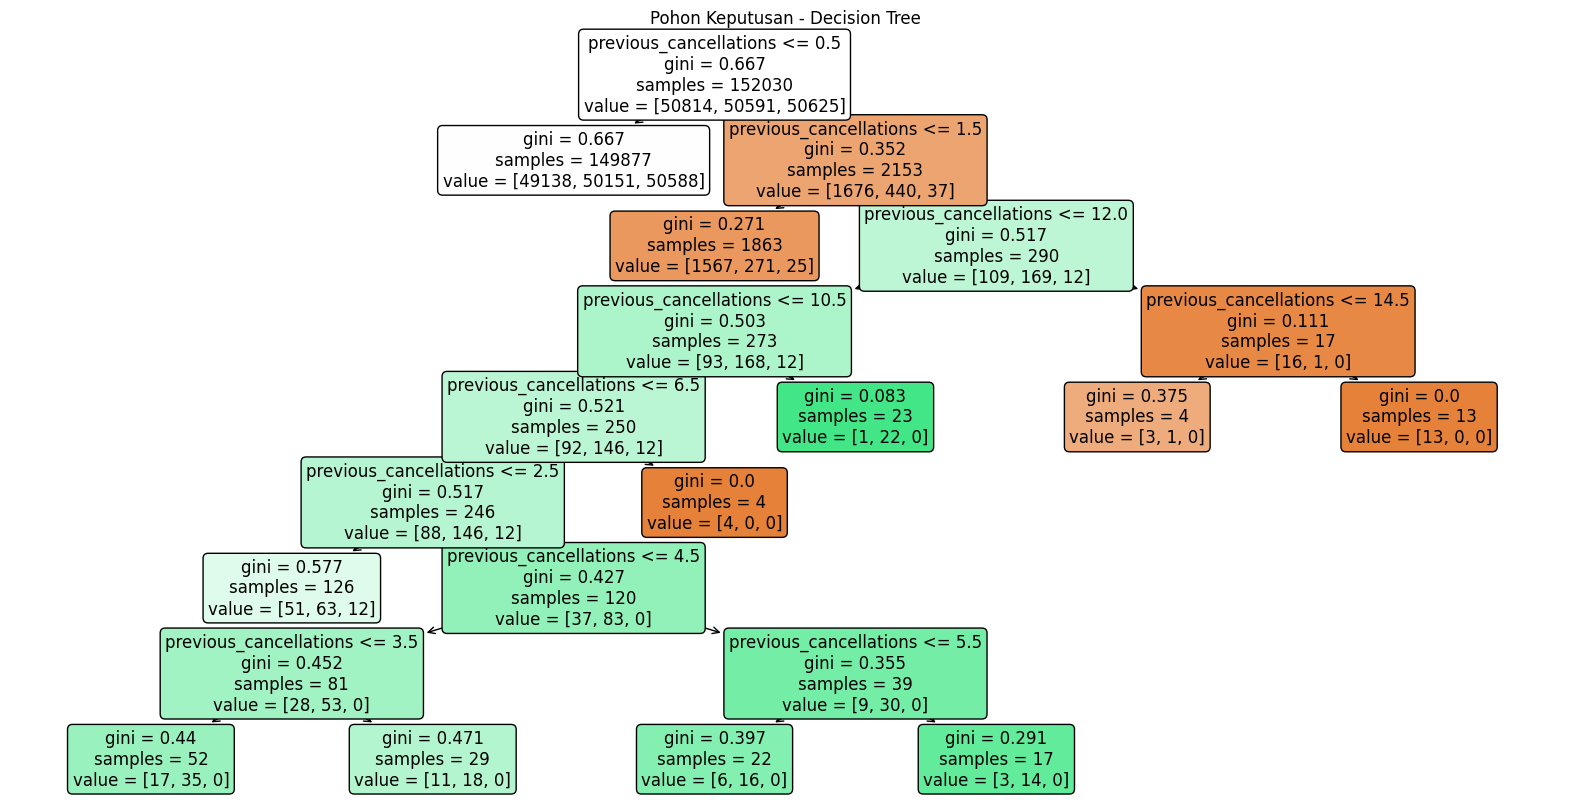

Logistic Regression Accuracy: 0.3447432119553778
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.77      0.03      0.06     12532
           1       0.00      0.00      0.00     12755
           2       0.34      1.00      0.51     12721

    accuracy                           0.34     38008
   macro avg       0.37      0.34      0.19     38008
weighted avg       0.37      0.34      0.19     38008



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


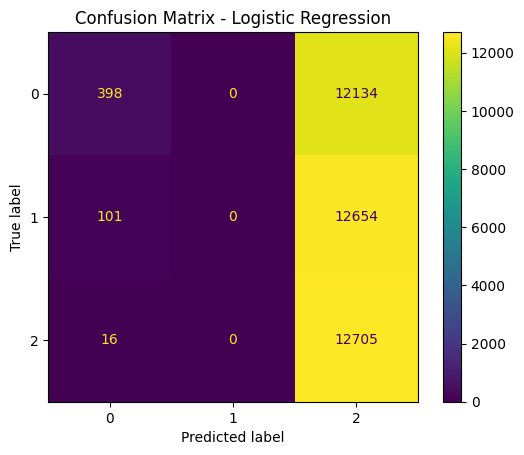

RandomForestClassifier(random_state=42)

In [ ]:
# Menggunakan fitur previous_cancellations
X_selected = X_resampled[['previous_cancellations']]
y = y_resampled

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=['previous_cancellations'], filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model


<h2>Algoritma untuk previous_bookings_not_canceled<h2>

Naive Bayes Accuracy: 0.34250684066512316
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

           0       0.34      1.00      0.50     12532
           1       0.74      0.03      0.06     12755
           2       0.31      0.01      0.02     12721

    accuracy                           0.34     38008
   macro avg       0.46      0.35      0.20     38008
weighted avg       0.46      0.34      0.19     38008



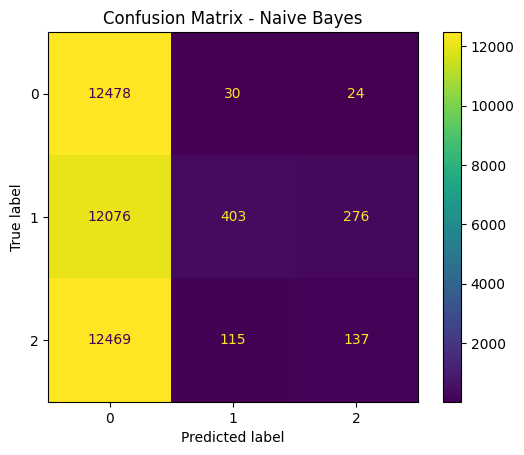

Decision Tree Accuracy: 0.34616396548095135
Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       0.34      1.00      0.50     12532
           1       0.69      0.05      0.10     12755
           2       0.50      0.00      0.00     12721

    accuracy                           0.35     38008
   macro avg       0.51      0.35      0.20     38008
weighted avg       0.51      0.35      0.20     38008



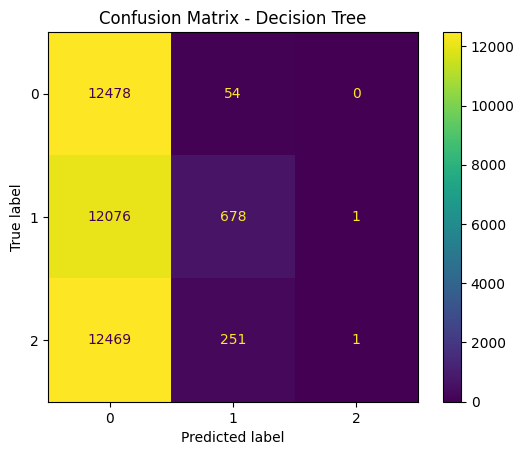

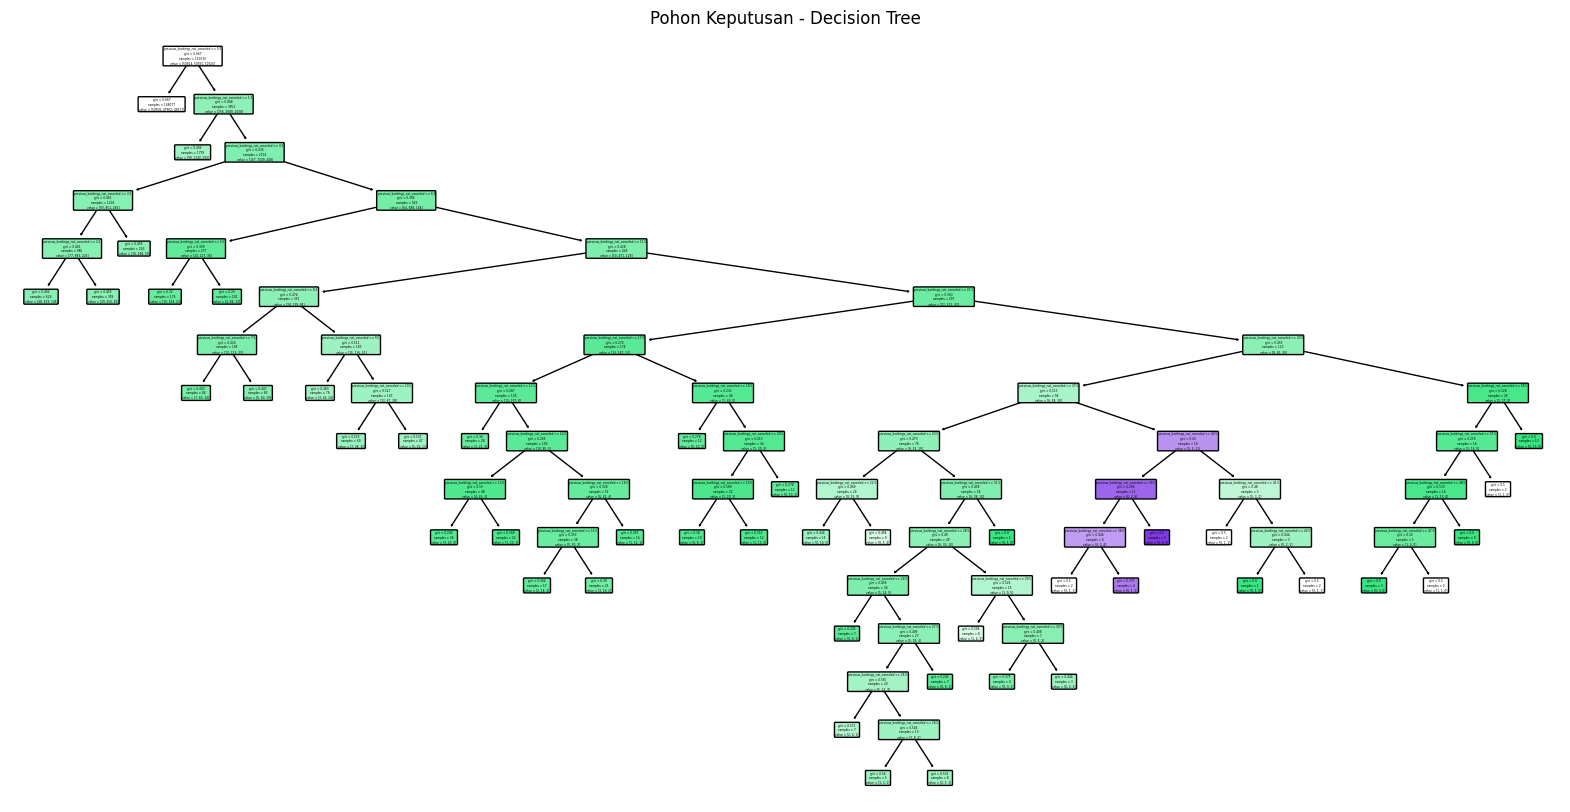

Logistic Regression Accuracy: 0.34616396548095135
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.34      1.00      0.50     12532
           1       0.69      0.05      0.10     12755
           2       0.00      0.00      0.00     12721

    accuracy                           0.35     38008
   macro avg       0.34      0.35      0.20     38008
weighted avg       0.34      0.35      0.20     38008



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


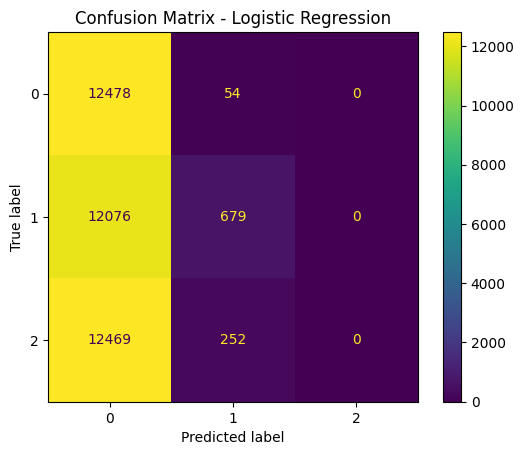

Random Forest Accuracy: 0.34621658598189853
Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.34      1.00      0.50     12532
           1       0.69      0.05      0.10     12755
           2       0.75      0.00      0.00     12721

    accuracy                           0.35     38008
   macro avg       0.59      0.35      0.20     38008
weighted avg       0.59      0.35      0.20     38008



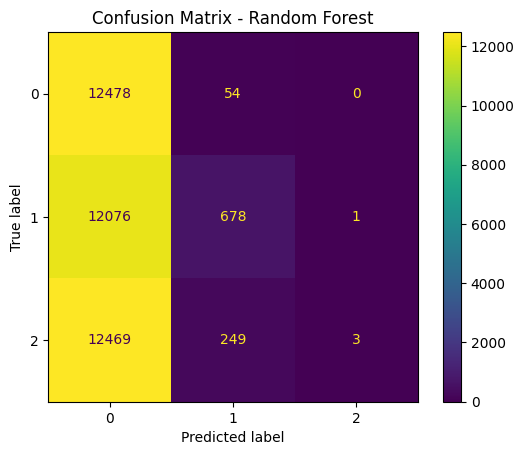

XGBoost Accuracy: 0.34621658598189853
Classification Report - XGBoost:
              precision    recall  f1-score   support

           0       0.34      1.00      0.50     12532
           1       0.69      0.05      0.10     12755
           2       0.75      0.00      0.00     12721

    accuracy                           0.35     38008
   macro avg       0.59      0.35      0.20     38008
weighted avg       0.59      0.35      0.20     38008



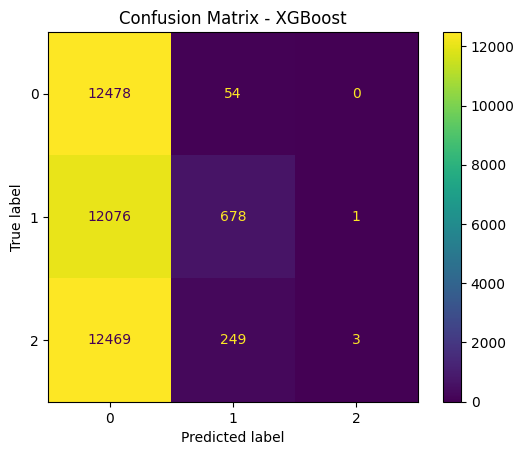

In [ ]:
# Menggunakan fitur previous_bookings_not_canceled
X_selected = X_resampled[['previous_bookings_not_canceled']]
y = y_resampled

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=['previous_bookings_not_canceled'], filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()

# XGBoost
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()


<h2>Algoritma untuk agent<h2>

Naive Bayes Accuracy: 0.363791833298253
Classification Report - Naive Bayes:
              precision    recall  f1-score   support

           0       0.27      0.01      0.01     12532
           1       0.37      0.28      0.31     12755
           2       0.36      0.80      0.50     12721

    accuracy                           0.36     38008
   macro avg       0.33      0.36      0.28     38008
weighted avg       0.33      0.36      0.28     38008



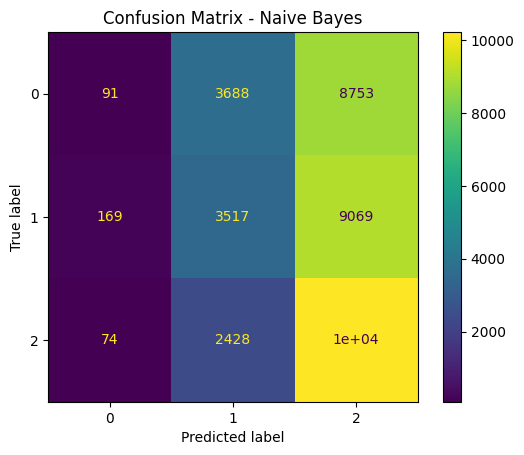

Decision Tree Accuracy: 0.5536466007156388
Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       0.47      0.74      0.57     12532
           1       0.59      0.58      0.58     12755
           2       0.78      0.35      0.48     12721

    accuracy                           0.55     38008
   macro avg       0.61      0.55      0.55     38008
weighted avg       0.61      0.55      0.55     38008



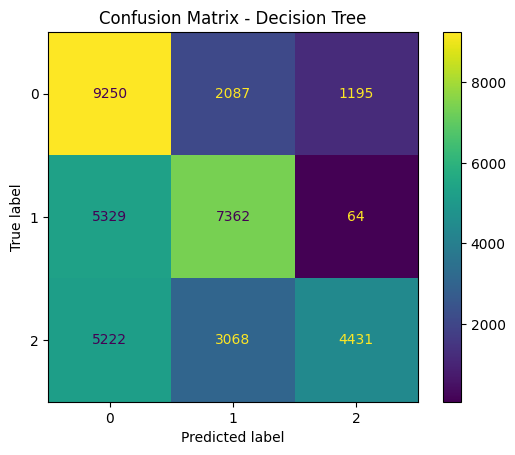

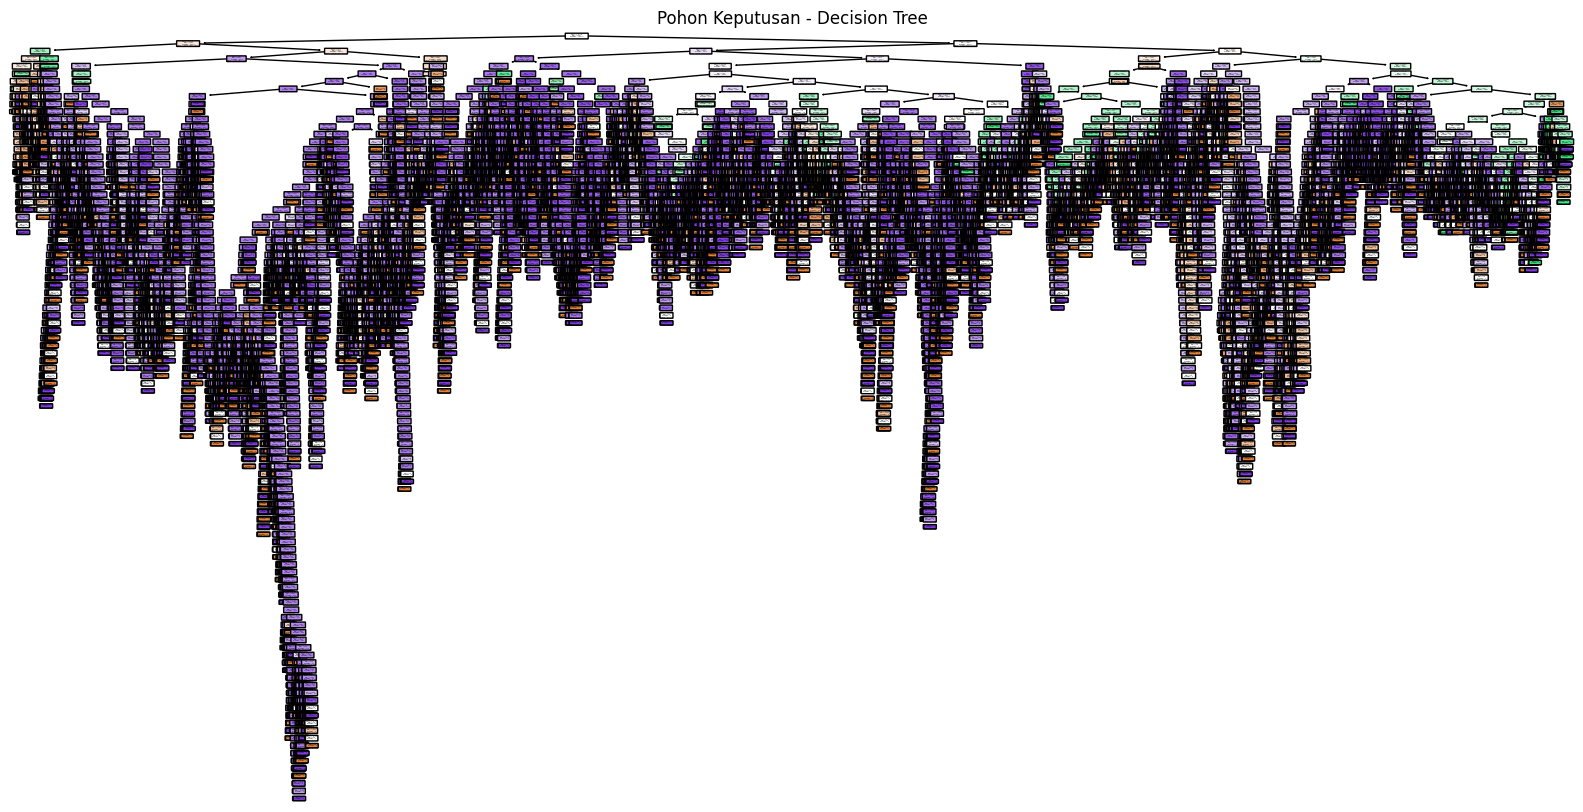

Logistic Regression Accuracy: 0.3098031993264576
Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.15      0.07      0.10     12532
           1       0.36      0.30      0.33     12755
           2       0.33      0.55      0.41     12721

    accuracy                           0.31     38008
   macro avg       0.28      0.31      0.28     38008
weighted avg       0.28      0.31      0.28     38008



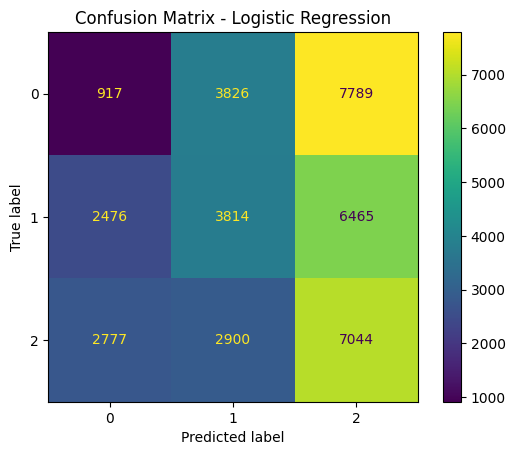

Random Forest Accuracy: 0.5536729109661124
Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.47      0.74      0.57     12532
           1       0.59      0.58      0.58     12755
           2       0.78      0.35      0.48     12721

    accuracy                           0.55     38008
   macro avg       0.61      0.55      0.55     38008
weighted avg       0.61      0.55      0.55     38008



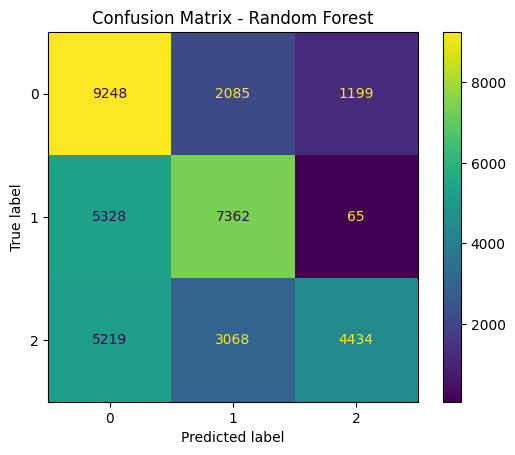

In [ ]:
# Menggunakan fitur agent
X_selected = X_resampled[['agent']]
y = y_resampled

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=['agent'], filled=True, rounded=True)
plt.title('Pohon Keputusan - Decision Tree')
plt.show()

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()

# XGBoost
xgb_model = xgb


SFS-Forward

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression

# Memilih fitur yang akan digunakan
features = ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list', 'previous_bookings_not_canceled']
X_selected = X_resampled[features]

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_resampled, test_size=0.2, random_state=42)

# Menggunakan Logistic Regression sebagai estimator
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Sequential Forward Selection
sfs = SFS(lr_model,
          k_features='best',
          forward=True,
          floating=False,
          scoring='accuracy',
          cv=5)

sfs = sfs.fit(X_train, y_train)

# Menampilkan hasil SFS
selected_features = list(sfs.k_feature_names_)
print(f"Selected features: {selected_features}")

# Menampilkan skor SFS
sfs_scores = sfs.get_metric_dict()
for k in sfs_scores.keys():
    print(f"Step {k}:")
    print(f"Features: {sfs_scores[k]['feature_idx']}")
    print(f"CV Score: {sfs_scores[k]['avg_score']}")


Selected features: ['lead_time', 'agent', 'is_canceled']
Step 1:
Features: (2,)
CV Score: 0.6670065118726567
Step 2:
Features: (0, 2)
CV Score: 0.7557324212326515
Step 3:
Features: (0, 1, 2)
CV Score: 0.7582450832072618
Step 4:
Features: (0, 1, 2, 4)
CV Score: 0.7581858843649281
Step 5:
Features: (0, 1, 2, 3, 4)
CV Score: 0.7582253502598171


SFS-Backward

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression

# Memilih fitur yang akan digunakan
features = ['lead_time', 'agent', 'is_canceled', 'days_in_waiting_list', 'previous_bookings_not_canceled']
X_selected = X_resampled[features]

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_resampled, test_size=0.2, random_state=42)

# Menggunakan Logistic Regression sebagai estimator
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Sequential Backward Selection
sbs = SFS(lr_model,
          k_features='best',
          forward=False,
          floating=False,
          scoring='accuracy',
          cv=5)

sbs = sbs.fit(X_train, y_train)

# Menampilkan hasil SBS
selected_features = list(sbs.k_feature_names_)
print(f"Selected features: {selected_features}")

# Menampilkan skor SBS
sbs_scores = sbs.get_metric_dict()
for k in sbs_scores.keys():
    print(f"Step {k}:")
    print(f"Features: {sbs_scores[k]['feature_idx']}")
    print(f"CV Score: {sbs_scores[k]['avg_score']}")


Selected features: ['lead_time', 'agent', 'is_canceled']
Step 5:
Features: (0, 1, 2, 3, 4)
CV Score: 0.7582253502598171
Step 4:
Features: (0, 1, 2, 4)
CV Score: 0.7581858843649281
Step 3:
Features: (0, 1, 2)
CV Score: 0.7582450832072618
Step 2:
Features: (0, 2)
CV Score: 0.7557324212326515
Step 1:
Features: (2,)
CV Score: 0.6670065118726567
